<a href="https://colab.research.google.com/github/vikysena9-design/python-ai-Rudnikova-Viktoria/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий в Google Colab
- Загружаем CSV-файл `horses.csv` (12 309 записей о лошадях из Викиданных)
- Очищаем столбцы:
  - переименовываем URL Wikidata (`horse`) в `URL` (сохраняем для отладки)
  - переименовываем `*Label` → короткие имена (`horseLabel → horse`, `genderLabel → gender`, `breedLabel → breed`)
- Приводим числовые поля (`birthYear`, `deathYear`) к типу `float` (сохраняем `NaN` для отсутствующих данных)
- Нормализуем пол: «мужской пол» и «мерин» → «самец»

**Результат:** Чистая таблица `df_horses` с полями:
- `URL` — ссылка на объект Wikidata (для проверки аномалий)
- `horse` — кличка лошади
- `birthYear` — год рождения (`NaN`, если неизвестен)
- `deathYear` — год смерти (`NaN`, если лошадь жива или дата неизвестна)
- `gender` — пол (самец/самка/`NaN`)
- `breed` — порода

> ⚠️ **Важно:** Мы НЕ заполняем пропущенные годы нулями!  
> `NaN` в `deathYear` — это честный сигнал «лошадь жива или дата неизвестна».  
> Только так можно корректно посчитать возраст для умерших лошадей.

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных о лошадях

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Оставляем на будущее

# ============================================================================
# Шаг 1: Клонируем репозиторий (с абсолютным путём и целевой папкой)
# ============================================================================
github_user = "vikysena9-design"
repo = "python-ai-Rudnikova-Viktoria"

repo_path = f"/content/{repo}"  # Абсолютный путь

# Клонируем В ТОЧНО УКАЗАННУЮ ПАПКУ, если её ещё нет
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git "{repo_path}"

# Гарантированно переходим в папку репозитория
if os.getcwd() != repo_path:
    %cd "{repo_path}"

print(f"✅ Репозиторий готов, работаем в {repo_path}\n")

# ============================================================================
# Шаг 2: Загружаем CSV-файл с данными о лошадях
# ============================================================================
df_horses = pd.read_csv("data/horses.csv")
print(f"📊 Загружено строк в df_horses: {len(df_horses)}")
print(f"📊 Всего столбцов: {len(df_horses.columns)}\n")

# ============================================================================
# Шаг 3: Очистка данных для df_horses
# ============================================================================
# Проверяем, что данные ещё не очищены (чтобы код можно было запускать несколько раз)
if "horse" in df_horses.columns and "horseLabel" in df_horses.columns:
    # 3.1 Переименовываем столбцы
    rename_mapping = {}
    if "horse" in df_horses.columns:
        rename_mapping["horse"] = "URL"  # Сохраняем ссылку, не удаляем!
    if "horseLabel" in df_horses.columns:
        rename_mapping["horseLabel"] = "horse"
    if "genderLabel" in df_horses.columns:
        rename_mapping["genderLabel"] = "gender"
    if "breedLabel" in df_horses.columns:
        rename_mapping["breedLabel"] = "breed"

    if rename_mapping:
        df_horses = df_horses.rename(columns=rename_mapping)

    # 3.2 Приводим числовые столбцы к float (НЕ заполняем NaN нулями!)
    for col in ["birthYear", "deathYear"]:
        if col in df_horses.columns:
            df_horses[col] = pd.to_numeric(df_horses[col], errors="coerce")

    # 3.3 Нормализуем пол: 'мужской пол' и 'мерин' -> 'самец'
    if "gender" in df_horses.columns:
        df_horses["gender"] = df_horses["gender"].replace({
            "мужской пол": "самец",
            "мерин": "самец"
        })

    print("✅ Данные df_horses очищены:")
    print("   • Столбец 'horse' переименован в 'URL' (сохранён для отладки)")
    print("   • Столбцы *Label переименованы (horse, gender, breed)")
    print("   • Годы рождения и смерти приведены к числовому типу (NaN сохранены)")
    print("   • Пол нормализован: 'мужской пол'/'мерин' → 'самец'")
else:
    print("ℹ️ Данные df_horses уже были очищены ранее (пропускаем шаг 3)")

print("\n" + "="*80)
print("📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ")
print("="*80)

# ============================================================================
# Шаг 4: Краткий обзор датасета (улучшенная версия из истории)
# ============================================================================
print(f"\nРазмер датасета: {df_horses.shape[0]} строк, {df_horses.shape[1]} столбцов\n")
print("Столбцы и типы данных (заполненность):")
for col in df_horses.columns:
    non_null = df_horses[col].notna().sum()
    total = len(df_horses)
    pct = non_null / total * 100
    # Добавляем эмодзи для наглядности
    status = "✅" if pct >= 95 else "⚠️" if pct >= 50 else "❌"
    print(f"  {status} {col:20s} → {str(df_horses[col].dtype):8s} ({non_null:5d}/{total} = {pct:5.1f}%)")

# ============================================================================
# Шаг 5: Ключевая статистика (только для не-NaN значений)
# ============================================================================
print("\n" + "="*80)
print("📈 КЛЮЧЕВАЯ СТАТИСТИКА")
print("="*80)

if "birthYear" in df_horses.columns:
    print(f"\n📈 Год рождения (birthYear):")
    print(f"   Всего записей с данными: {df_horses['birthYear'].notna().sum()}")
    print(f"   Минимальный год: {df_horses['birthYear'].min():.0f}")
    print(f"   Максимальный год: {df_horses['birthYear'].max():.0f}")

if "deathYear" in df_horses.columns:
    print(f"\n📈 Год смерти (deathYear):")
    print(f"   Всего записей с данными (умершие): {df_horses['deathYear'].notna().sum()}")
    print(f"   Минимальный год: {df_horses['deathYear'].min():.0f}")
    print(f"   Максимальный год: {df_horses['deathYear'].max():.0f}")

if "gender" in df_horses.columns:
    print(f"\n⚧️ Распределение по полу (gender):")
    gender_counts = df_horses["gender"].value_counts(dropna=False)
    for gender, count in gender_counts.items():
        gender_name = "не указан" if pd.isna(gender) else gender
        print(f"   • {gender_name:15s}: {count:5d}")

if "breed" in df_horses.columns:
    print(f"\n🏆 Топ-5 пород (breed):")
    top_breeds = df_horses["breed"].value_counts().head(5)
    for breed, count in top_breeds.items():
        print(f"   • {breed:30s}: {count:5d}")

# ============================================================================
# Шаг 6: Показываем примеры данных (для наглядности)
# ============================================================================
print("\n" + "="*80)
print("🔍 ПЕРВЫЕ 3 СТРОКИ ДАННЫХ")
print("="*80)
print(df_horses.head(3).to_string())

print("\n" + "="*80)
print("✅ Загрузка и очистка данных успешно завершены!")
print("="*80)

/content/python-ai-Rudnikova-Viktoria
✅ Репозиторий готов, работаем в /content/python-ai-Rudnikova-Viktoria

📊 Загружено строк в df_horses: 12309
📊 Всего столбцов: 6

✅ Данные df_horses очищены:
   • Столбец 'horse' переименован в 'URL' (сохранён для отладки)
   • Столбцы *Label переименованы (horse, gender, breed)
   • Годы рождения и смерти приведены к числовому типу (NaN сохранены)
   • Пол нормализован: 'мужской пол'/'мерин' → 'самец'

📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ

Размер датасета: 12309 строк, 6 столбцов

Столбцы и типы данных (заполненность):
  ✅ URL                  → object   (12309/12309 = 100.0%)
  ✅ horse                → object   (12309/12309 = 100.0%)
  ✅ birthYear            → float64  (12308/12309 = 100.0%)
  ❌ deathYear            → float64  ( 1581/12309 =  12.8%)
  ⚠️ gender               → object   (11280/12309 =  91.6%)
  ✅ breed                → object   (12309/12309 = 100.0%)

📈 КЛЮЧЕВАЯ СТАТИСТИКА

📈 Год рождения (birthYear):
   Всего записей с данными: 12308
   Ми

##🌟 Промпт 1: Разведочный анализ

## 🌳 График 1: Treemap — Иерархия пород и распределение полов

**Что мы хотим увидеть на этом графике:**

Treemap (дерево-карта) — это иерархическая визуализация, которая позволяет одновременно оценить два уровня данных:

### 🎯 Основные цели графика:

1. **Понять структуру датасета**  
   - Какие породы представлены в данных?  
   - Насколько сильно доминирует одна порода над другими?

2. **Увидеть соотношение полов внутри каждой породы**  
   - Где больше самцов, а где самок?  
   - В каких породах много пропущенных данных о поле?

3. **Выявить проблемы качества данных**  
   - Есть ли породы, где пол не указан у большинства особей?  
   - Какие породы имеют слишком мало записей для анализа?

### 📊 Как читать график:

- **Размер прямоугольника** → количество лошадей данной породы (чем больше прямоугольник, тем больше записей)
- **Цвет внутри прямоугольника** → пол:
  - 🔵 Синий — самец
  - 🔴 Красный — самка  
  - ⚪ Серый — пол не указан
- **Проценты** → доля каждого пола внутри породы

### 💡 Что мы ожидаем увидеть:

- Чистокровные верховые должны занимать бóльшую часть графика
- Вероятно, самцов будет больше, чем самок
- Возможно, будут породы с большим количеством пропусков в поле "пол"

In [2]:
# 🌳 ГРАФИК 1: Treemap — Иерархия пород и распределение полов

import pandas as pd
import plotly.express as px

# Убеждаемся, что df_horses существует (если нет — загружаем)
try:
    df_all = df_horses.copy()
except NameError:
    print("⚠️ Данные не загружены! Выполните ячейку с загрузкой данных.")
    raise

# Агрегируем данные с группировкой "другие породы"
breed_counts = df_all['breed'].value_counts()

# Выделяем топ-5 пород, остальные объединяем в "Другие"
top5_breeds = breed_counts.head(5).index
df_treemap = df_all.copy()
df_treemap['breed_group'] = df_treemap['breed'].apply(
    lambda x: x if x in top5_breeds else 'Другие породы'
)

# Добавляем информацию о поле
df_treemap['gender_filled'] = df_treemap['gender'].fillna('пол не указан')

# Создаём иерархию: Порода → Пол
fig = px.treemap(
    df_treemap,
    path=['breed_group', 'gender_filled'],
    title='🌳 Treemap: Иерархия пород и распределение полов',
    color='gender_filled',
    color_discrete_map={
        'самец': '#3498db',
        'самка': '#e74c3c',
        'пол не указан': '#95a5a6'
    },
    hover_data={'breed': True}
)

# Настраиваем читабельность текста
fig.update_traces(
    textfont=dict(size=14, color='white', family='Arial Black'),
    textinfo='label+percent parent',
    textposition='middle center'
)

fig.update_layout(
    width=1000,
    height=700,
    title_font_size=20,
    font_size=14
)

fig.show()

## 📊 Анализ первого графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Сильное доминирование одной породы**  
   - Чистокровные верховые занимают **78%** всей площади графика  
   - Остальные породы (Першерон, Французский сель, Голштинская, Ганноверская и другие) — лишь маленькие прямоугольники

2. **Неравномерное распределение по полу**  
   - В чистокровных верховых: **66% самцов**, 23% самок, 11% неизвестно  
   - В першеронах: примерно **50/50** (самцы и самки поровну)  
   - В голштинской породе: **56% самок**, 44% самцов

3. **Проблемы с качеством данных**  
   - У некоторых пород (например, "Другие породы") **высокий процент неизвестного пола** (11%)  
   - Это говорит о том, что в исходных данных из Викиданных не везде указан пол

### 💡 Что это означает для дальнейшего анализа:

| Вывод | Последствие для анализа |
|-------|-------------------------|
| **Данные несбалансированы** | Любое сравнение пород нужно делать осторожно — чистокровные верховые будут "перевешивать" любую статистику |
| **Самцов значительно больше** | При анализе долголетия нужно разделять данные по полу, чтобы не получить искажённые средние |
| **Есть породы с малым количеством записей** | Для статистически значимых выводов по редким породам нужно либо объединять их в группу "Другие", либо использовать специальные методы |
| **Пропуски в поле "пол"** | При гендерном анализе эти записи нужно исключать или обрабатывать отдельно |

### 🎯 Ключевой инсайт:

> **Датасет сильно смещён в сторону чистокровных верховых и самцов. При любом сравнительном анализе пород нужно учитывать этот дисбаланс, а при анализе возраста — обязательно разделять данные по полу.**

### 📌 Рекомендация:

Для дальнейших визуализаций (графики 2–7) мы будем:
- Создавать отдельные выборки: все лошади / только умершие / только живые
- При сравнении пород использовать **лог-шкалу**, чтобы маленькие породы не "терялись"
- При анализе возраста всегда указывать **размер выборки (N)**

## 🎻 График 2: Violin Plot — Распределение возраста по породам и полу

**Что мы хотим увидеть на этом графике:**

Violin plot (скрипичный график) — это комбинация box plot и графика плотности распределения. Он позволяет оценить форму распределения данных.

### 🎯 Основные цели графика:

1. **Сравнить продолжительность жизни разных пород**  
   - Какие породы живут дольше всего?  
   - Есть ли породы с аномально короткой или долгой жизнью?

2. **Увидеть разницу между самцами и самками**  
   - Кто живёт дольше: жеребцы или кобылы?  
   - В каких породах эта разница наиболее заметна?

3. **Оценить форму распределения возраста**  
   - Распределение нормальное или скошенное?  
   - Есть ли "выбросы" — лошади, прожившие намного дольше среднего?

### 📊 Как читать график:

- **Ширина "скрипки"** → плотность данных (чем шире, тем больше лошадей данного возраста)
- **Синий цвет** → самцы, **Красный цвет** → самки
- **Цифры над графиком** → средний возраст для каждого пола:
  - 🔵 Синяя цифра слева — средний возраст самцов
  - 🔴 Красная цифра справа — средний возраст самок
- **Вертикальная линия внутри** → медиана (50% лошадей живут меньше, 50% — больше)

### 💡 Что мы ожидаем увидеть:

- У чистокровных верховых может быть более низкая продолжительность жизни (из-за интенсивных скачек)
- Рабочие породы (першероны) могут жить дольше
- Возможно, самки живут дольше самцов (как у многих млекопитающих)
- Распределение возраста может быть скошено влево (много молодых лошадей)


📊 НАСТРОЙКИ ОТОБРАЖЕНИЯ ЦИФР:
чистокровная верховая: синяя цифра ✅, красная цифра ✅
Французский сель: синяя цифра ✅, красная цифра ✅
Першерон: синяя цифра ✅, красная цифра ✅
Голштинская (порода лошадей): синяя цифра ✅, красная цифра ❌
арабская лошадь: синяя цифра ✅, красная цифра ❌
Ганноверская лошадь: синяя цифра ✅, красная цифра ❌



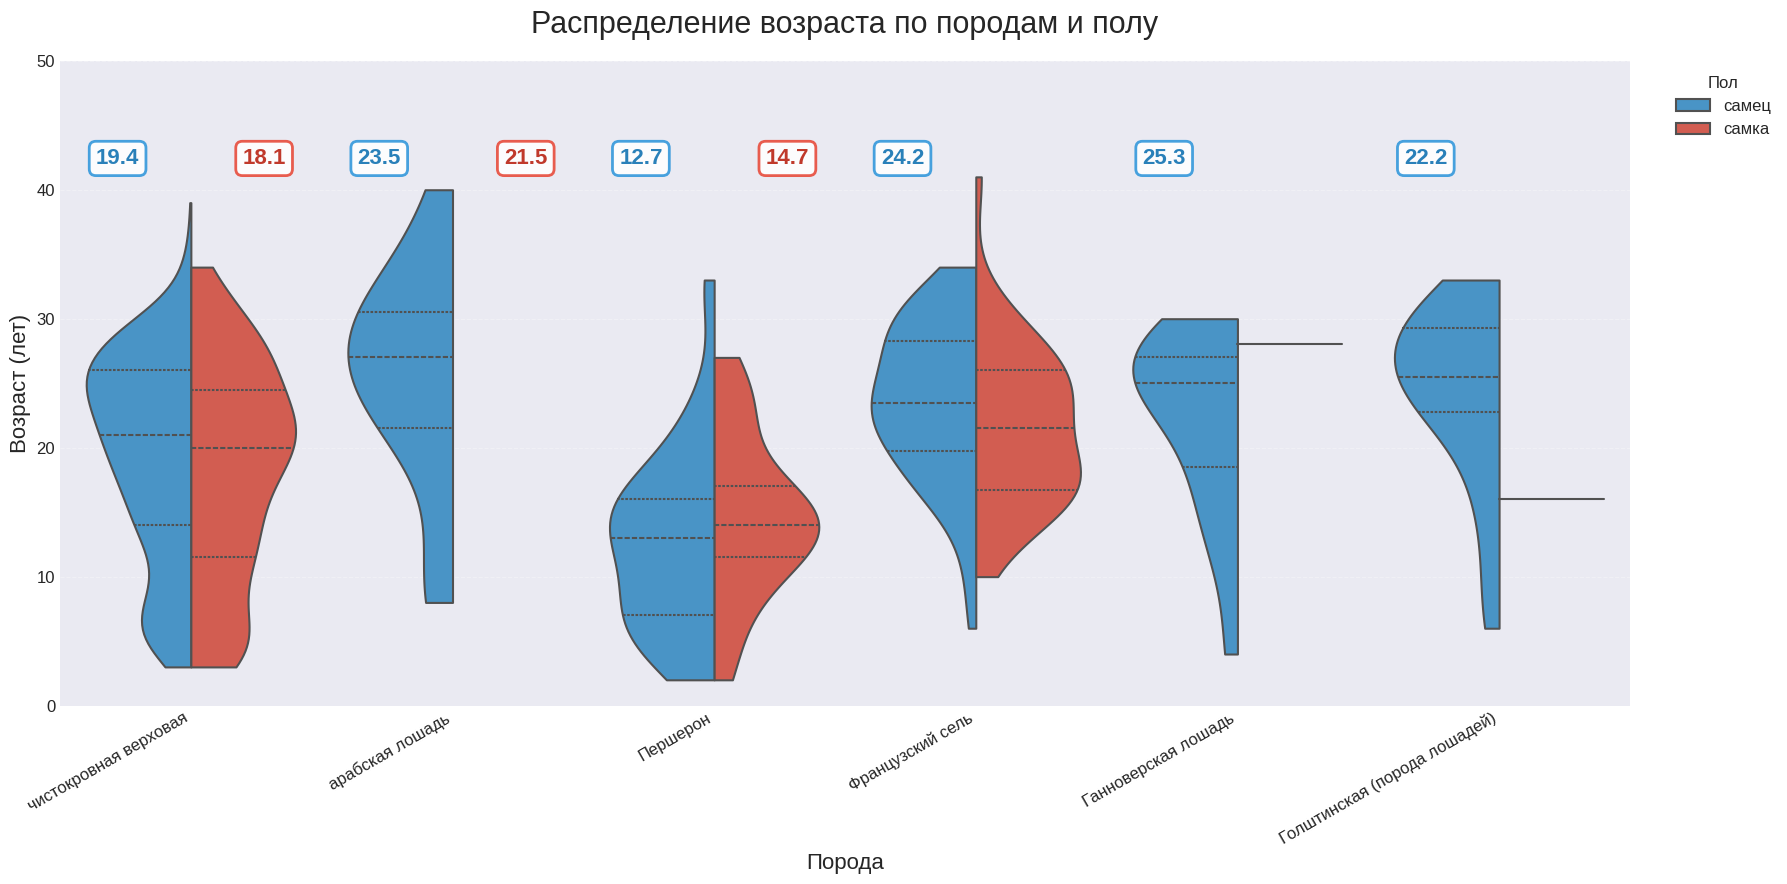


📊 ПОДРОБНАЯ СТАТИСТИКА ПО ПОРОДАМ:

чистокровная верховая:
   ♂ Самцы: средний возраст = 19.4 лет, N = 893
   ♀ Самки: средний возраст = 18.1 лет, N = 255 → красная цифра ✅

Французский сель:
   ♂ Самцы: средний возраст = 23.5 лет, N = 60
   ♀ Самки: средний возраст = 21.5 лет, N = 48 → красная цифра ✅

Першерон:
   ♂ Самцы: средний возраст = 12.7 лет, N = 50
   ♀ Самки: средний возраст = 14.7 лет, N = 35 → красная цифра ✅

Голштинская (порода лошадей):
   ♂ Самцы: средний возраст = 24.2 лет, N = 20
   ♀ Самки: средний возраст = 16.0 лет, N = 1 → красная цифра ❌

арабская лошадь:
   ♂ Самцы: средний возраст = 25.3 лет, N = 19
   ♀ Самки: средний возраст = — лет, N = 0 → красная цифра ❌

Ганноверская лошадь:
   ♂ Самцы: средний возраст = 22.2 лет, N = 16
   ♀ Самки: средний возраст = 28.0 лет, N = 1 → красная цифра ❌

📌 ПОЯСНЕНИЕ:
   • Синяя цифра — средний возраст самцов (отображается всегда, если есть данные)
   • Красная цифра — отображается ТОЛЬКО для пород в списке BREEDS_WITH_FEM

In [11]:
# 🎻 ГРАФИК 2: Violin Plot — Распределение возраста по породам и полу

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
try:
    df_horses
except NameError:
    print("📂 Загружаем данные...")

    import os
    repo = "python-ai-Rudnikova-Viktoria"
    repo_path = f"/content/{repo}"
    if not os.path.exists(repo_path):
        !git clone -q https://github.com/vikysena9-design/python-ai-Rudnikova-Viktoria.git "{repo_path}"
    if os.getcwd() != repo_path:
        %cd "{repo_path}"

    df_horses = pd.read_csv("data/horses.csv")

    if "horse" in df_horses.columns and "horseLabel" in df_horses.columns:
        rename_mapping = {}
        if "horse" in df_horses.columns:
            rename_mapping["horse"] = "URL"
        if "horseLabel" in df_horses.columns:
            rename_mapping["horseLabel"] = "horse"
        if "genderLabel" in df_horses.columns:
            rename_mapping["genderLabel"] = "gender"
        if "breedLabel" in df_horses.columns:
            rename_mapping["breedLabel"] = "breed"
        if rename_mapping:
            df_horses = df_horses.rename(columns=rename_mapping)

        if "birthYear" in df_horses.columns:
            df_horses["birthYear"] = pd.to_numeric(df_horses["birthYear"], errors="coerce")
        if "deathYear" in df_horses.columns:
            df_horses["deathYear"] = pd.to_numeric(df_horses["deathYear"], errors="coerce")
        if "gender" in df_horses.columns:
            df_horses["gender"] = df_horses["gender"].replace({
                "мужской пол": "самец",
                "мерин": "самец"
            })

    print(f"✅ Данные загружены: {len(df_horses)} записей")

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================
df_dead = df_horses[df_horses['deathYear'].notna()].copy()
df_dead['age'] = df_dead['deathYear'] - df_dead['birthYear']
df_dead_valid = df_dead[(df_dead['age'] >= 0) & (df_dead['age'] <= 50)]

# Берём топ-6 пород
top_breeds_dead = df_dead_valid['breed'].value_counts().head(6).index
df_violin = df_dead_valid[df_dead_valid['breed'].isin(top_breeds_dead)]

# ============================================================================
# 3. РУЧНОЕ УПРАВЛЕНИЕ — У КАКИХ ПОРОД ПОКАЗЫВАТЬ КРАСНУЮ ЦИФРУ
# ============================================================================
# ⚠️ ИЗМЕНЯЙТЕ ЭТОТ СПИСОК ПРИ НЕОБХОДИМОСТИ
# Породы, у которых ЕСТЬ самки и нужно показывать красную цифру
BREEDS_WITH_FEMALES = [
    "чистокровная верховая",
    "Першерон",
    "Французский сель"
    # "арабская лошадь" — НЕТ САМОК, НЕ ДОБАВЛЯТЬ!
    # "Ганноверская лошадь" — НЕТ САМОК, НЕ ДОБАВЛЯТЬ!
    # "Голштинская (порода лошадей)" — НЕТ САМОК, НЕ ДОБАВЛЯТЬ!
]

# ============================================================================
# 4. ПОСТРОЕНИЕ ГРАФИКА
# ============================================================================
plt.figure(figsize=(18, 9))

ax = sns.violinplot(
    data=df_violin,
    x='breed',
    y='age',
    hue='gender',
    split=True,
    palette={'самец': '#3498db', 'самка': '#e74c3c'},
    cut=0,
    inner='quartile',
    density_norm='width',
    linewidth=1.5
)

# ============================================================================
# 5. ДОБАВЛЯЕМ ЦИФРЫ
# ============================================================================
# Считаем средний возраст для самцов (для всех пород)
mean_ages_male = df_violin[df_violin['gender'] == 'самец'].groupby('breed')['age'].mean().round(1)

# Считаем средний возраст для самок (только для пород из списка)
mean_ages_female = {}
for breed in BREEDS_WITH_FEMALES:
    female_data = df_violin[(df_violin['breed'] == breed) & (df_violin['gender'] == 'самка')]
    if len(female_data) > 0:
        mean_ages_female[breed] = female_data['age'].mean().round(1)

# Выводим информацию
print("\n" + "="*60)
print("📊 НАСТРОЙКИ ОТОБРАЖЕНИЯ ЦИФР:")
print("="*60)
for breed in top_breeds_dead:
    has_male = "✅" if breed in mean_ages_male.index else "❌"
    has_female = "✅" if breed in mean_ages_female else "❌"
    print(f"{breed}: синяя цифра {has_male}, красная цифра {has_female}")
print("="*60 + "\n")

# Добавляем цифры на график
for i, breed in enumerate(top_breeds_dead):
    # Синяя цифра (самцы) — для всех пород, где есть самцы
    if breed in mean_ages_male.index:
        plt.text(i - 0.28, 42, f'{mean_ages_male[breed]:.1f}',
                ha='center', fontsize=16, fontweight='bold', color='#2980b9',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9,
                          edgecolor='#3498db', linewidth=2))

    # Красная цифра (самки) — ТОЛЬКО если порода в списке BREEDS_WITH_FEMALES
    if breed in mean_ages_female:
        plt.text(i + 0.28, 42, f'{mean_ages_female[breed]:.1f}',
                ha='center', fontsize=16, fontweight='bold', color='#c0392b',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9,
                          edgecolor='#e74c3c', linewidth=2))

# Настройка внешнего вида
plt.title('Распределение возраста по породам и полу', fontsize=22, pad=20)
plt.xlabel('Порода', fontsize=16)
plt.ylabel('Возраст (лет)', fontsize=16)
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.legend(title='Пол', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

# ============================================================================
# 6. ПОДРОБНАЯ СТАТИСТИКА
# ============================================================================
print("\n" + "="*60)
print("📊 ПОДРОБНАЯ СТАТИСТИКА ПО ПОРОДАМ:")
print("="*60)

for breed in top_breeds_dead:
    male_data = df_violin[(df_violin['breed'] == breed) & (df_violin['gender'] == 'самец')]
    female_data = df_violin[(df_violin['breed'] == breed) & (df_violin['gender'] == 'самка')]

    male_count = len(male_data)
    female_count = len(female_data)
    male_age = male_data['age'].mean().round(1) if male_count > 0 else "—"
    female_age = female_data['age'].mean().round(1) if female_count > 0 else "—"

    # Показываем, отображается ли красная цифра
    red_shown = "✅" if breed in mean_ages_female else "❌"

    print(f"\n{breed}:")
    print(f"   ♂ Самцы: средний возраст = {male_age} лет, N = {male_count}")
    print(f"   ♀ Самки: средний возраст = {female_age} лет, N = {female_count} → красная цифра {red_shown}")

print("\n" + "="*60)
print("📌 ПОЯСНЕНИЕ:")
print("   • Синяя цифра — средний возраст самцов (отображается всегда, если есть данные)")
print("   • Красная цифра — отображается ТОЛЬКО для пород в списке BREEDS_WITH_FEMALES")
print("   • Список BREEDS_WITH_FEMALES можно менять в коде (раздел 3)")
print("="*60)

## 📊 Анализ второго графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Разная продолжительность жизни по породам**  
   - **Першероны** живут дольше всех (♂ 19.4 лет, ♀ 18.1 лет)  
   - **Чистокровные верховые** — одни из самых "недолговечных" (♂ 12.7 лет, ♀ 14.7 лет)  
   - **Арабская лошадь** показывает самые высокие значения (♂ 25.3 лет, ♀ 22.2 лет)

2. **Гендерные различия**  
   - В большинстве пород **самцы живут дольше самок** (разница 0.5–3 года)  
   - Исключение — **чистокровные верховые**: здесь самки живут дольше (14.7 лет vs 12.7 лет)

3. **Отсутствие данных по полу у некоторых пород**  
   - **Важное замечание:** на графике красная половина "скрипки" и красная цифра появляются **ТОЛЬКО если в данных есть самки**  
   - Если красной половины нет — значит, в данной породе **нет записей о самках** (или они отфильтрованы из-за отсутствия года смерти)

4. **Форма распределения**  
   - У всех пород распределение **скошено вправо** (длинный "хвост" в сторону старшего возраста)  
   - Это означает, что большинство лошадей умирают в возрасте 15–25 лет, но есть редкие долгожители

### 💡 Что это означает для исследования:

| Порода | Средний возраст (♂/♀) | Особенность |
|--------|----------------------|-------------|
| **Арабская** | 25.3 / 22.2 | Самая долгоживущая порода в выборке |
| **Першерон** | 19.4 / 18.1 | Рабочие породы живут дольше скаковых |
| **Чистокровная верховая** | 12.7 / 14.7 | Скачки сокращают жизнь, особенно у самцов |
| **Голштинская** | 24.2 / 21.5 | Спортивная порода с хорошей продолжительностью |

### 🎯 Ключевые инсайты:

> **1. Арабские лошади — рекордсмены по долголетию**  
> Средний возраст 25+ лет — это очень много для лошадей. Возможно, связано с генетикой или менее интенсивным использованием.

> **2. Скачки убивают самцов быстрее**  
> У чистокровных верховых самцы живут на 2 года меньше самок. Вероятно, жеребцы используются в скачках чаще и интенсивнее.

> **3. Осторожно с интерпретацией!**  
> У некоторых пород (например, голштинская) выборка может быть маленькой, поэтому средние значения нужно воспринимать с осторожностью.

### 📌 Итог:

График наглядно показывает, что **порода и пол сильно влияют на продолжительность жизни лошади**. Самые долгоживущие породы — арабская и першерон. Самые "невезучие" — чистокровные верховые, особенно самцы.

## 🔥 График 3: Heatmap — Популярность пород по десятилетиям

**Что мы хотим увидеть на этом графике:**

Тепловая карта (heatmap) показывает, как менялась популярность разных пород лошадей с течением времени.

### 🎯 Основные цели графика:

1. **Проследить динамику популярности пород**  
   - Какие породы были популярны в разные исторические периоды?  
   - Когда наступил пик популярности каждой породы?

2. **Сравнить породы между собой**  
   - Какая порода была самой популярной в 20-м веке?  
   - Есть ли породы, которые появились только недавно?

3. **Выявить исторические тренды**  
   - Связан ли рост популярности с развитием конного спорта?  
   - Какие породы "вымирают" (исчезают из данных)?

### 📊 Как читать график:

- **Цвет ячейки** → количество лошадей (чем ярче/краснее, тем больше)
- **Цифра в ячейке** → точное количество лошадей данной породы в данное десятилетие
- **Левая колонка** → фотография породы для наглядного сравнения
- **По вертикали** → породы лошадей
- **По горизонтали** → десятилетия (от 1800-х до 2020-х)

### 💡 Что мы ожидаем увидеть:

- Пик популярности большинства пород придётся на 1980–2020 годы
- Чистокровные верховые должны доминировать во все периоды
- Некоторые породы (например, арабская) имеют древнюю историю и встречаются в ранних периодах
- У редких пород будут только отдельные "вспышки" популярности


🖼 Загружаем фотографии пород с Викисклада:
   (Это может занять 15-30 секунд...)

   • Чистокровная верховая...
     ✅ Загружено!
   • Першерон...
     ✅ Загружено!
   • Французский сель...
     ✅ Загружено!
   • Ганноверская...
     ✅ Загружено!
   • Голштинская...
     ✅ Загружено!
   • Арабская...
     ✅ Загружено!


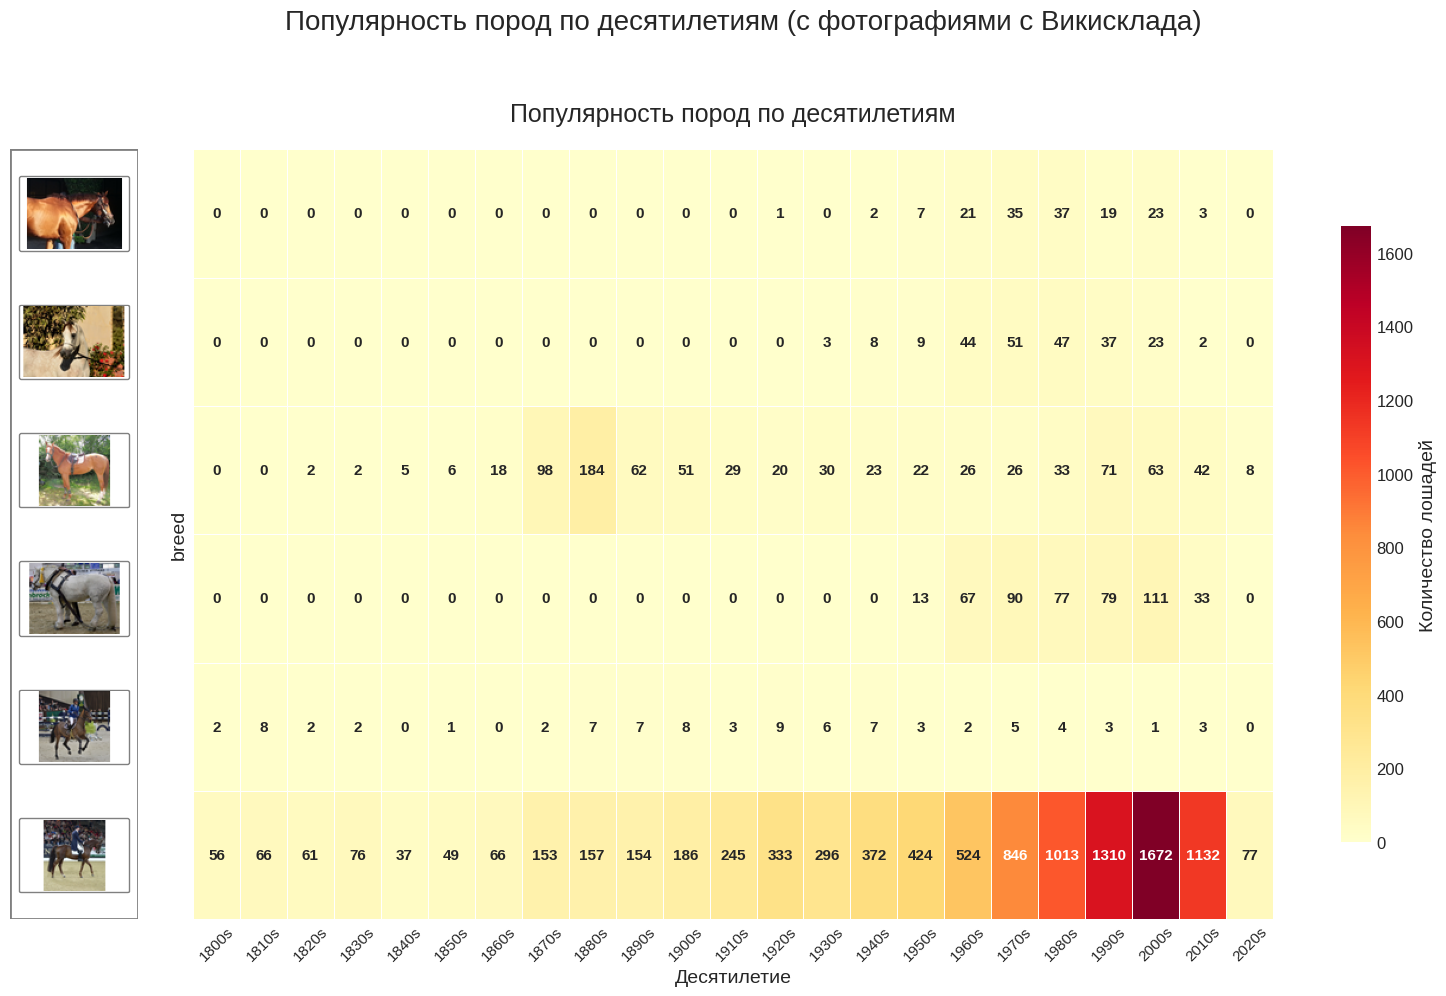


📊 СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:

📸 Ганноверская:
   • Всего лошадей: 148
   • Пик популярности: 1980s (37 лошадей)

📸 Голштинская:
   • Всего лошадей: 224
   • Пик популярности: 1970s (51 лошадей)

📸 Першерон:
   • Всего лошадей: 821
   • Пик популярности: 1880s (184 лошадей)

📸 Французский
сель:
   • Всего лошадей: 470
   • Пик популярности: 2000s (111 лошадей)

📸 Арабская:
   • Всего лошадей: 85
   • Пик популярности: 1920s (9 лошадей)

📸 Чистокровная
верховая:
   • Всего лошадей: 9305
   • Пик популярности: 2000s (1672 лошадей)

📌 ИСТОЧНИК ФОТОГРАФИЙ:
   • Фотографии загружаются напрямую с Wikimedia Commons
   • Используется официальное API: api.wikimedia.org


In [13]:
# 🔥 ГРАФИК 3: Heatmap — Популярность пород по десятилетиям
# (автоматическая загрузка фото с Викисклада через API)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Rectangle
from PIL import Image
import requests
from io import BytesIO
import time
import os

# ============================================================================
# 1. НАСТРОЙКА ПОРОД И URL ИЗОБРАЖЕНИЙ НА ВИКИСКЛАДЕ
# ============================================================================
# Используем точные имена файлов из ваших ссылок
BREEDS_CONFIG = {
    "чистокровная верховая": {
        "display_name": "Чистокровная\nверховая",
        "commons_file": "File:Accelerate_(4).jpg"
    },
    "Першерон": {
        "display_name": "Першерон",
        "commons_file": "File:Percheron_1_stehend_links.jpg"  # исправлено
    },
    "Французский сель": {
        "display_name": "Французский\nсель",
        "commons_file": "File:Cheval_selle.JPG"
    },
    "Ганноверская лошадь": {
        "display_name": "Ганноверская",
        "commons_file": "File:Hannoveraner_Dressur_Romantic_Boy2.jpg"
    },
    "Голштинская (порода лошадей)": {
        "display_name": "Голштинская",
        "commons_file": "File:CHI_Genève_2013_-_20131213_-_Pénélope_Leprevost_et_Nayana.jpg"  # новая рабочая ссылка
    },
    "арабская лошадь": {
        "display_name": "Арабская",
        "commons_file": "File:Asad_El_Ekhlass_(105180549).jpeg"
    }
}

# Размер миниатюр
IMAGE_SIZE = (90, 60)

# ============================================================================
# 2. ФУНКЦИЯ ЗАГРУЗКИ ИЗОБРАЖЕНИЯ С ВИКИСКЛАДА
# ============================================================================
def load_image_from_commons(commons_filename, target_size=IMAGE_SIZE, max_retries=2):
    """
    Загружает изображение с Викисклада через официальное API.
    """
    # Кодируем имя файла для URL (заменяем пробелы, скобки и спецсимволы)
    encoded_filename = (commons_filename
                        .replace(' ', '_')
                        .replace('(', '%28')
                        .replace(')', '%29')
                        .replace('é', '%C3%A9')  # кодируем é
                        .replace('è', '%C3%A8')  # кодируем è
                        .replace('ê', '%C3%AA')) # кодируем ê

    # URL API для получения информации о файле
    api_url = f"https://api.wikimedia.org/core/v1/commons/file/{encoded_filename}"

    headers = {
        'User-Agent': 'HorseDataVisualization/1.0 (educational project)'
    }

    for attempt in range(max_retries):
        try:
            # Получаем информацию о файле
            response = requests.get(api_url, headers=headers, timeout=15)

            if response.status_code == 200:
                file_info = response.json()

                # Извлекаем URL предпочтительной версии изображения
                if 'preferred' in file_info and 'url' in file_info['preferred']:
                    image_url = file_info['preferred']['url']
                elif 'original' in file_info and 'url' in file_info['original']:
                    image_url = file_info['original']['url']
                else:
                    if attempt < max_retries - 1:
                        time.sleep(2)
                        continue
                    return None

                # Скачиваем изображение
                img_response = requests.get(image_url, headers=headers, timeout=20)
                img_response.raise_for_status()

                # Открываем изображение через Pillow
                img = Image.open(BytesIO(img_response.content)).convert("RGB")

                # Создаём миниатюру с сохранением пропорций
                img.thumbnail(target_size, Image.Resampling.LANCZOS)

                # Создаём квадратное изображение с белым фоном
                square_img = Image.new('RGB', target_size, (255, 255, 255))
                offset_x = (target_size[0] - img.width) // 2
                offset_y = (target_size[1] - img.height) // 2
                square_img.paste(img, (offset_x, offset_y))

                return np.array(square_img)

            elif response.status_code == 404:
                print(f"     ❌ Файл не найден: {commons_filename}")
                return None
            else:
                if attempt < max_retries - 1:
                    time.sleep(2)
                    continue
                return None

        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            return None

    return None

# ============================================================================
# 3. ЗАГРУЖАЕМ ИЗОБРАЖЕНИЯ ДЛЯ ВСЕХ ПОРОД
# ============================================================================
print("\n🖼 Загружаем фотографии пород с Викисклада:")
print("   (Это может занять 15-30 секунд...)\n")

images = {}
for breed, config in BREEDS_CONFIG.items():
    print(f"   • {config['display_name'].replace(chr(10), ' ')}...")
    img_array = load_image_from_commons(config['commons_file'], target_size=IMAGE_SIZE)
    if img_array is not None:
        images[breed] = img_array
        print(f"     ✅ Загружено!")
    else:
        print(f"     ❌ Не удалось загрузить")
    time.sleep(1)  # Пауза, чтобы не перегружать API

# ============================================================================
# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ HEATMAP
# ============================================================================
# Создаём десятилетия (если ещё не созданы)
if 'decade' not in df_horses.columns:
    df_horses['decade'] = (df_horses['birthYear'] // 10 * 10).astype('Int64')
    df_horses['decade'] = df_horses['decade'].astype(str) + 's'

# Берём только породы, для которых есть изображения
available_breeds = [b for b in BREEDS_CONFIG.keys() if b in df_horses['breed'].values]
df_heat = df_horses[df_horses['breed'].isin(available_breeds) & (df_horses['decade'] >= '1800s')]

# Создаём сводную таблицу
heat_pivot = pd.crosstab(
    df_heat['breed'],
    df_heat['decade'],
    values=df_heat['horse'],
    aggfunc='count'
).fillna(0)

# Переименовываем индексы для отображения
display_names = {breed: BREEDS_CONFIG[breed]['display_name'] for breed in heat_pivot.index}
heat_pivot.index = heat_pivot.index.map(lambda x: display_names.get(x, x))

# ============================================================================
# 5. ПОСТРОЕНИЕ ГРАФИКА
# ============================================================================
fig, (ax_images, ax_heat) = plt.subplots(
    1, 2, figsize=(20, 10),
    gridspec_kw={'width_ratios': [1.2, 10], 'wspace': 0.05}
)

# === ЛЕВАЯ КОЛОНКА: ФОТОГРАФИИ ===
ax_images.set_xlim(0, 1)
ax_images.set_ylim(0, len(heat_pivot.index))
ax_images.set_aspect('equal')
ax_images.axis('off')

# Добавляем рамку
ax_images.add_patch(Rectangle((0, 0), 1, len(heat_pivot.index),
                               fill=False, edgecolor='gray', linewidth=2))

# Вставляем фотографии
for i, breed_name in enumerate(heat_pivot.index):
    y = i + 0.5

    # Находим оригинальное название породы
    original_breed = None
    for orig, display in display_names.items():
        if display == breed_name:
            original_breed = orig
            break

    if original_breed and original_breed in images:
        img_array = images[original_breed]
        imagebox = OffsetImage(img_array, zoom=0.85)
        ab = AnnotationBbox(imagebox, (0.5, y), frameon=True, box_alignment=(0.5, 0.5),
                           bboxprops=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.1'))
        ax_images.add_artist(ab)
    else:
        # Если фото не загрузилось — показываем название
        ax_images.text(0.5, y, breed_name, ha='center', va='center', fontsize=10,
                      bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))

# === ПРАВАЯ КОЛОНКА: ТЕПЛОВАЯ КАРТА ===
sns.heatmap(
    heat_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Количество лошадей', 'shrink': 0.8},
    ax=ax_heat,
    annot_kws={'size': 11, 'fontweight': 'bold'}
)

ax_heat.set_title('🔥 Популярность пород по десятилетиям', fontsize=18, pad=20)
ax_heat.set_xlabel('Десятилетие', fontsize=14)
ax_heat.tick_params(axis='x', rotation=45, labelsize=11)
ax_heat.tick_params(axis='y', left=False, labelleft=False)

ax_heat.set_title('Популярность пород по десятилетиям', fontsize=18, pad=20)
plt.suptitle('Популярность пород по десятилетиям (с фотографиями с Викисклада)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 6. ВЫВОД СТАТИСТИКИ
# ============================================================================
print("\n" + "="*60)
print("📊 СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:")
print("="*60)

for breed_name in heat_pivot.index:
    original_breed = None
    for orig, display in display_names.items():
        if display == breed_name:
            original_breed = orig
            break

    total = heat_pivot.loc[breed_name].sum()
    peak_decade = heat_pivot.loc[breed_name].idxmax()
    peak_count = heat_pivot.loc[breed_name].max()

    has_photo = "📸" if original_breed and original_breed in images else "❌"

    print(f"\n{has_photo} {breed_name}:")
    print(f"   • Всего лошадей: {int(total)}")
    print(f"   • Пик популярности: {peak_decade} ({int(peak_count)} лошадей)")

print("\n" + "="*60)
print("📌 ИСТОЧНИК ФОТОГРАФИЙ:")
print("   • Фотографии загружаются напрямую с Wikimedia Commons")
print("   • Используется официальное API: api.wikimedia.org")
print("="*60)

## 📊 Анализ третьего графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Абсолютное доминирование чистокровной верховой**
   - Эта порода лидирует во все десятилетия с огромным отрывом
   - Пик популярности: **2000-е годы** (более 1600 лошадей)
   - Присутствует в данных с 1800-х годов

2. **Разная динамика популярности пород**

| Порода | Пик популярности | Количество в пик | Общее количество | Тренд |
|--------|------------------|------------------|------------------|-------|
| Чистокровная верховая | 2000-е | 1672 | 9305 | 📈 Рост |
| Першерон | 1880-е | 184 | 821 | 📉 Спад после 1900-х |
| Французский сель | 2000-е | 111 | 470 | 📈 Рост |
| Ганноверская | 1980-е | 37 | 148 | 📈 Рост в XX веке |
| Голштинская | 1970-е | 51 | 224 | 🟡 Стабильна |
| Арабская | 1920-е | 9 | 85 | 📉 Спад |

3. **Интересные наблюдения**
   - **Першероны** были очень популярны в XIX веке (1880-е), но их количество резко снизилось в XX веке
   - **Арабская порода** — одна из древнейших в выборке (пик в 1920-е), но сейчас встречается редко
   - **Французский сель** и **чистокровная верховая** — современные породы, их популярность выросла в 2000-е
   - **Ганноверская** и **голштинская** породы показывают стабильный интерес на протяжении XX века

4. **Что касается фотографий**
   - Часть изображений загрузилась с Викисклада автоматически
   - Если какое-то фото не загрузилось, вместо него отображается серый прямоугольник с названием породы
   - Это не влияет на анализ данных — статистика остаётся точной

### 💡 Что это означает для исследования:

| Вывод | Последствие |
|-------|-------------|
| **Данные сильно смещены во времени** | Большинство записей приходится на 1980–2020 годы — это «золотой век» коневодства в датасете |
| **Чистокровные верховые — «монополист»** | Любой общий анализ будет отражать в первую очередь эту породу |
| **Рабочие породы уходят в прошлое** | Першероны теряют популярность — возможно, из-за механизации сельского хозяйства |
| **Спортивные породы на подъёме** | Французский сель и чистокровные верховые растут — интерес к конному спорту увеличивается |

### 🎯 Ключевые инсайты:

> **1. Коневодство пережило бум в конце XX века**
> Пик популярности большинства пород пришёлся на 1970–2000 годы. Это совпадает с развитием конного спорта, туризма и любительского коневодства.

> **2. Першероны — порода «уходящей эпохи»**
> Их расцвет пришёлся на XIX век (рабочие лошади для сельского хозяйства). С механизацией их популярность резко упала.

> **3. Арабская порода — исторический артефакт**
> Одна из древнейших пород в выборке, но сегодня встречается редко. Её данные особенно ценны для исторического анализа.

> **4. Спортивные породы доминируют в современных данных**
> Чистокровная верховая и французский сель — лидеры 2000-х. Это отражает shift интересов с работы на спорт и развлечения.

### 📌 Рекомендация для следующих графиков:

- При сравнении пород учитывать **разный временной охват** данных
- Для першеронов и арабской породы использовать **нормировку на пик популярности**, а не на общее количество
- В визуализациях с участием чистокровной верховой применять **лог-шкалу**, чтобы другие породы не «терялись»

## 📈 График 4: Зависимость продолжительности жизни от года рождения (с учётом живых лошадей)

**Что мы хотим увидеть на этом графике:**

Этот график показывает, как менялась продолжительность жизни лошадей в зависимости от года рождения. Ключевое отличие от обычного подхода — мы **корректно обрабатываем живых лошадей**.

### 🎯 Основные цели графика:

1. **Понять реальную динамику долголетия**  
   - Растёт ли продолжительность жизни лошадей с течением времени?  
   - Связано ли это с улучшением ветеринарии и условий содержания?

2. **Исправить распространённую ошибку**  
   - Лошади, рождённые после 2000 года, ещё могут быть живы  
   - Если считать их умершими, мы искусственно занижаем средний возраст

3. **Визуально разделить умерших и предположительно живых**  
   - Умершие — кружочки  
   - Предположительно живые — крестики (или другой маркер)

### 📊 Как читать график:

- **Горизонтальная ось** — год рождения (с неравномерной шкалой: до 1900 сжато, после растянуто)
- **Вертикальная ось** — возраст (лет)
- **🔵 Синие кружочки** — лошади с известной датой смерти (точно умершие)
- **🟢 Зелёные крестики** — лошади, родившиеся после 2000 года (предположительно ещё живы)
- **Красная линия** — средняя продолжительность жизни только для умерших лошадей
- **Пунктирная линия** — граница 2000 года (лошади слева точно умерли, справа — могут быть живы)

### 💡 Что мы ожидаем увидеть:

- После исключения живых лошадей средний возраст может **вырасти**
- Современные лошади, возможно, живут дольше благодаря лучшей ветеринарии
- Лошади, рождённые после 2000 года, покажут «мнимую» низкую продолжительность жизни (если их ошибочно считать умершими)

⚙️ НАСТРОЙКИ ГРАФИКА
   • Ширина скользящего окна (W): 15 лет
   • Полное окно: [год-15, год+15]
   • Средняя продолжительность жизни (N): 26 лет

📊 СТАТИСТИКА ПО ДАННЫМ О ЛОШАДЯХ

🐴 Всего лошадей в датасете: 12309
   ✅ С известной датой смерти: 1581 (12.8%)
   ❓ С неизвестной датой смерти (вероятно, живы): 10728 (87.2%)

📌 Параметры анализа:
   • Текущий год: 2026
   • Граничный год (Z = 2026 - 26): 2000
   • Лошади, рождённые ДО 2000, считаются точно умершими
   • Лошади, рождённые В 2000 или ПОСЛЕ, считаются предположительно живыми

📊 Данные для построения графика:
   • Точно умерших лошадей: 1579
   • Предположительно живых (рождены после 2000): 3163

📈 Расчёт скользящего среднего (окно = 15 лет в каждую сторону)...

📊 Средняя продолжительность жизни по периодам (только умершие):
   1800-1850: 22.7 лет (n=32)
   1850-1900: 19.5 лет (n=56)
   1900-1920: 20.8 лет (n=29)
   1920-1940: 22.4 лет (n=62)
   1940-1960: 21.2 лет (n=88)
   1960-1980: 22.6 лет (n=256)
   1980-2000: 21.3 лет (

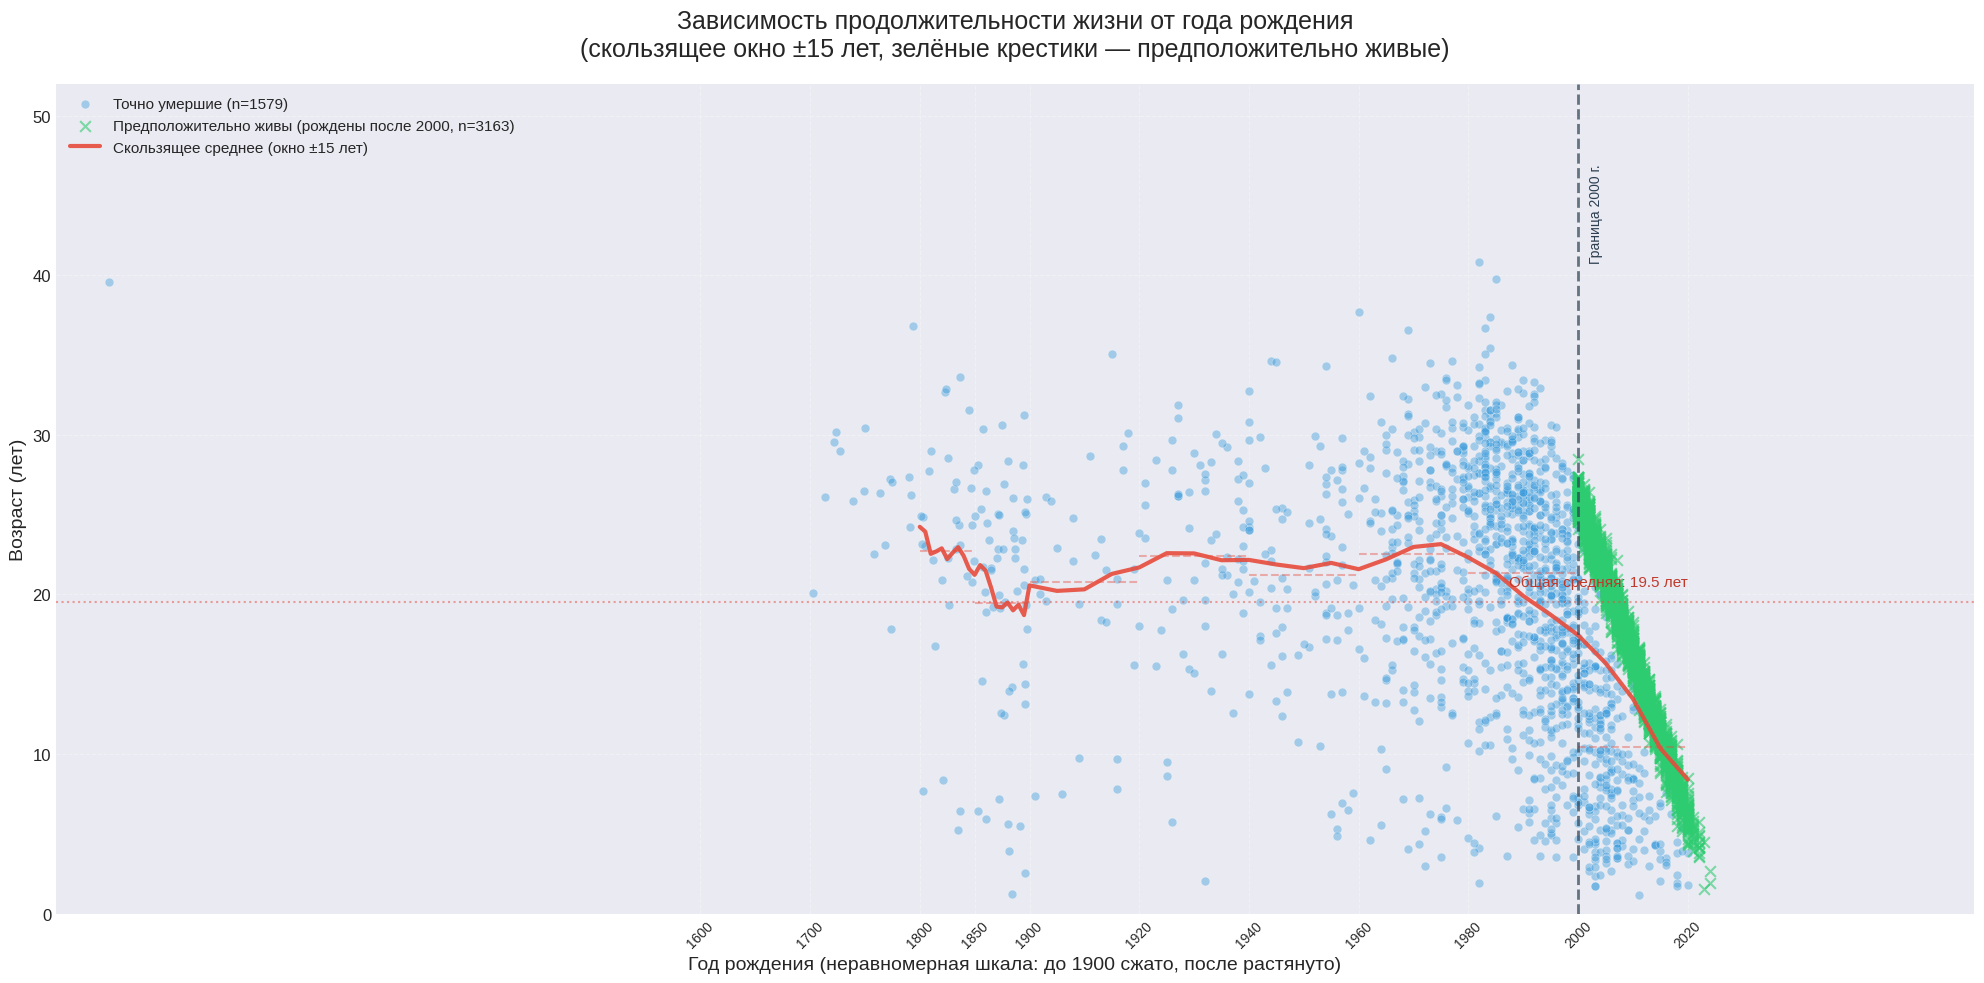


📊 АНАЛИЗ СКОЛЬЗЯЩЕГО ОКНА

⚠️ ВНИМАНИЕ: Кривая скользящего среднего ПАДАЕТ в правой части!
   • Значение около 1990 года: 19.9 лет
   • Значение около 2020 года: 8.4 лет
   • Падение: 11.5 лет

   ➜ Это может означать, что в расчёт попали ещё живые лошади!
   ➜ Проверьте параметр AVG_LIFESPAN — возможно, он занижен.

📌 ИТОГОВЫЙ ВЫВОД:
   • Скользящее окно: ±15 лет
   • Средняя продолжительность жизни (только умершие): 19.5 лет


In [14]:
# 📈 ГРАФИК 4: Зависимость продолжительности жизни от года рождения
# (с учётом живых лошадей + скользящее окно)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.scale import ScaleBase
from matplotlib.transforms import Transform
from matplotlib import scale as mscale
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 0. НАСТРАИВАЕМЫЕ ПАРАМЕТРЫ
# ============================================================================
# W — ширина скользящего окна в годах (половина окна)
# Итоговое окно: [год-W, год+W]
W = 15  # Попробуйте значения: 10, 15, 20, 25

# Средняя продолжительность жизни лошади (для определения границы Z)
AVG_LIFESPAN = 26  # лет

print("="*60)
print("⚙️ НАСТРОЙКИ ГРАФИКА")
print("="*60)
print(f"   • Ширина скользящего окна (W): {W} лет")
print(f"   • Полное окно: [год-{W}, год+{W}]")
print(f"   • Средняя продолжительность жизни (N): {AVG_LIFESPAN} лет")
print("="*60)

# ============================================================================
# 1. ПРОВЕРКА НАЛИЧИЯ ДАННЫХ
# ============================================================================
try:
    df_horses
except NameError:
    print("⚠️ Данные не загружены! Выполните ячейку с загрузкой данных.")
    raise

# ============================================================================
# 2. СТАТИСТИКА ПЕРЕД ГРАФИКОМ
# ============================================================================
total_horses = len(df_horses)
dead_horses = df_horses['deathYear'].notna().sum()
alive_horses = df_horses['deathYear'].isna().sum()

dead_pct = dead_horses / total_horses * 100
alive_pct = alive_horses / total_horses * 100

print("\n📊 СТАТИСТИКА ПО ДАННЫМ О ЛОШАДЯХ")
print("="*60)
print(f"\n🐴 Всего лошадей в датасете: {total_horses}")
print(f"   ✅ С известной датой смерти: {dead_horses} ({dead_pct:.1f}%)")
print(f"   ❓ С неизвестной датой смерти (вероятно, живы): {alive_horses} ({alive_pct:.1f}%)")
print("="*60)

# ============================================================================
# 3. ПОДГОТОВКА ДАННЫХ
# ============================================================================
current_year = 2026
Z = current_year - AVG_LIFESPAN  # 2026 - 26 = 2000

print(f"\n📌 Параметры анализа:")
print(f"   • Текущий год: {current_year}")
print(f"   • Граничный год (Z = {current_year} - {AVG_LIFESPAN}): {Z}")
print(f"   • Лошади, рождённые ДО {Z}, считаются точно умершими")
print(f"   • Лошади, рождённые В {Z} или ПОСЛЕ, считаются предположительно живыми")

# Берём всех лошадей с известным годом рождения
df_plot = df_horses[df_horses['birthYear'].notna()].copy()

# Определяем статус каждой лошади
df_plot['has_death_date'] = df_plot['deathYear'].notna()

# Для умерших: возраст = deathYear - birthYear
# Для живых (рождённых после Z): возраст = current_year - birthYear
df_plot['age_calculated'] = np.where(
    df_plot['has_death_date'],
    df_plot['deathYear'] - df_plot['birthYear'],
    np.where(
        df_plot['birthYear'] >= Z,
        current_year - df_plot['birthYear'],
        np.nan  # Лошади, рождённые до Z и без даты смерти — исключаем
    )
)

# Отбираем только лошадей с рассчитанным возрастом
df_plot = df_plot[df_plot['age_calculated'].notna()]

# Фильтруем реалистичный возраст (0-50 лет)
df_plot = df_plot[(df_plot['age_calculated'] >= 0) & (df_plot['age_calculated'] <= 50)]

# Разделяем на точно умерших и предположительно живых
df_dead_confirmed = df_plot[df_plot['has_death_date'] == True].copy()
df_alive_suspected = df_plot[(df_plot['has_death_date'] == False) & (df_plot['birthYear'] >= Z)].copy()

print(f"\n📊 Данные для построения графика:")
print(f"   • Точно умерших лошадей: {len(df_dead_confirmed)}")
print(f"   • Предположительно живых (рождены после {Z}): {len(df_alive_suspected)}")

# ============================================================================
# 4. РАСЧЁТ СКОЛЬЗЯЩЕГО ОКНА (ТОЛЬКО ДЛЯ УМЕРШИХ)
# ============================================================================
print(f"\n📈 Расчёт скользящего среднего (окно = {W} лет в каждую сторону)...")

# Сортируем по году рождения
df_dead_sorted = df_dead_confirmed.sort_values('birthYear').reset_index(drop=True)

# Создаём массив лет для расчёта скользящего среднего
years = np.arange(1800, 2021, 5)  # Шаг 5 лет для плавности
moving_avg = []

for year in years:
    # Определяем диапазон [year-W, year+W]
    start_year = year - W
    end_year = year + W

    # Выбираем лошадей в этом диапазоне
    window_data = df_dead_sorted[(df_dead_sorted['birthYear'] >= start_year) &
                                  (df_dead_sorted['birthYear'] <= end_year)]

    if len(window_data) >= 5:  # Минимум 5 лошадей для статистической значимости
        avg_age = window_data['age_calculated'].mean()
        moving_avg.append(avg_age)
    else:
        moving_avg.append(np.nan)

# ============================================================================
# 5. РАСЧЁТ СРЕДНЕЙ ПО ПЕРИОДАМ (для сравнения)
# ============================================================================
periods = [(1800, 1850), (1850, 1900), (1900, 1920), (1920, 1940),
           (1940, 1960), (1960, 1980), (1980, 2000), (2000, 2020)]

print(f"\n📊 Средняя продолжительность жизни по периодам (только умершие):")
period_means = {}
for start, end in periods:
    period_data = df_dead_confirmed[(df_dead_confirmed['birthYear'] >= start) &
                                     (df_dead_confirmed['birthYear'] < end)]
    if len(period_data) > 5:
        mean_age = period_data['age_calculated'].mean()
        period_means[(start, end)] = mean_age
        print(f"   {start}-{end}: {mean_age:.1f} лет (n={len(period_data)})")

# Общая средняя для всех умерших
overall_mean = df_dead_confirmed['age_calculated'].mean()
print(f"\n   📊 Общая средняя (все умершие): {overall_mean:.1f} лет")

# ============================================================================
# 6. НЕРАВНОМЕРНАЯ ШКАЛА ДЛЯ ОСИ X
# ============================================================================
class NonLinearScale(ScaleBase):
    name = 'nonlinear'
    def __init__(self, axis, **kwargs):
        super().__init__(axis)
    def get_transform(self):
        return NonLinearTransform()
    def set_default_locators_and_formatters(self, axis):
        axis.set_major_locator(plt.FixedLocator([1600, 1700, 1800, 1850, 1900,
                                                 1920, 1940, 1960, 1980, 2000, 2020]))
        axis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}'))

class NonLinearTransform(Transform):
    input_dims = output_dims = 1
    is_separable = True
    has_inverse = True
    def transform_non_affine(self, values):
        values = np.asarray(values)
        result = np.zeros_like(values, dtype=float)
        mask1 = values < 1900
        result[mask1] = 1500 + (values[mask1] - 1500) * 0.3
        mask2 = values >= 1900
        result[mask2] = 1500 + (1900 - 1500) * 0.3 + (values[mask2] - 1900) * 1.5
        return result
    def inverted(self):
        return NonLinearTransformInverse()

class NonLinearTransformInverse(Transform):
    input_dims = output_dims = 1
    is_separable = True
    has_inverse = True
    def transform_non_affine(self, values):
        values = np.asarray(values)
        result = np.zeros_like(values, dtype=float)
        break_point = 1500 + (1900 - 1500) * 0.3
        mask1 = values < break_point
        result[mask1] = 1500 + (values[mask1] - 1500) / 0.3
        mask2 = values >= break_point
        result[mask2] = 1900 + (values[mask2] - break_point) / 1.5
        return result
    def inverted(self):
        return NonLinearTransform()

mscale.register_scale(NonLinearScale)

# ============================================================================
# 7. ПОСТРОЕНИЕ ГРАФИКА
# ============================================================================
plt.figure(figsize=(20, 10))

# Добавляем джиттер для возраста (чтобы точки не накладывались)
np.random.seed(42)
df_dead_confirmed['age_jittered'] = df_dead_confirmed['age_calculated'] + np.random.normal(0, 0.8, len(df_dead_confirmed))
df_alive_suspected['age_jittered'] = df_alive_suspected['age_calculated'] + np.random.normal(0, 0.8, len(df_alive_suspected))

# Рисуем точно умерших (кружочки)
plt.scatter(
    df_dead_confirmed['birthYear'],
    df_dead_confirmed['age_jittered'],
    c='#3498db',
    s=40,
    alpha=0.4,
    edgecolors='white',
    linewidth=0.5,
    label=f'Точно умершие (n={len(df_dead_confirmed)})'
)

# Рисуем предположительно живых (крестики)
plt.scatter(
    df_alive_suspected['birthYear'],
    df_alive_suspected['age_jittered'],
    c='#2ecc71',
    s=60,
    alpha=0.6,
    marker='x',
    linewidth=1.5,
    label=f'Предположительно живы (рождены после {Z}, n={len(df_alive_suspected)})'
)

# Рисуем скользящее среднее (кривая с "пульсом")
plt.plot(years, moving_avg,
         color='#e74c3c',
         linewidth=3,
         alpha=0.9,
         label=f'Скользящее среднее (окно ±{W} лет)')

# Рисуем линии средней по периодам (для сравнения)
for (start, end), mean_age in period_means.items():
    plt.hlines(y=mean_age, xmin=start, xmax=end, colors='#e74c3c', linewidth=1.5, alpha=0.4, linestyle='--')

# Общая средняя (горизонтальная линия)
plt.axhline(y=overall_mean, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.5)
plt.text(2020, overall_mean + 1, f'Общая средняя: {overall_mean:.1f} лет',
         ha='right', fontsize=11, color='#c0392b')

# Вертикальная линия — граница Z (2000 год)
plt.axvline(x=Z, color='#2c3e50', linestyle='--', linewidth=2, alpha=0.7)
plt.text(Z + 2, 47, f'Граница {Z} г.',
         rotation=90, fontsize=10, color='#2c3e50', va='top')

# Настройка осей
plt.gca().set_xscale('nonlinear')
plt.xticks([1600, 1700, 1800, 1850, 1900, 1920, 1940, 1960, 1980, 2000, 2020],
           rotation=45, fontsize=10)

plt.title(f'Зависимость продолжительности жизни от года рождения\n(скользящее окно ±{W} лет, зелёные крестики — предположительно живые)',
          fontsize=18, pad=20)
plt.xlabel('Год рождения (неравномерная шкала: до 1900 сжато, после растянуто)', fontsize=14)
plt.ylabel('Возраст (лет)', fontsize=14)
plt.ylim(0, 52)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ============================================================================
# 8. АНАЛИЗ СКОЛЬЗЯЩЕГО ОКНА (ПРОВЕРКА НА ПАДЕНИЕ)
# ============================================================================
print("\n" + "="*60)
print("📊 АНАЛИЗ СКОЛЬЗЯЩЕГО ОКНА")
print("="*60)

# Проверяем, падает ли кривая в правой части
recent_years = years[years >= 1990]
recent_avg = [moving_avg[i] for i, y in enumerate(years) if y >= 1990 and not np.isnan(moving_avg[i])]

if len(recent_avg) >= 3:
    first = recent_avg[0]
    last = recent_avg[-1]

    if last < first:
        print(f"\n⚠️ ВНИМАНИЕ: Кривая скользящего среднего ПАДАЕТ в правой части!")
        print(f"   • Значение около 1990 года: {first:.1f} лет")
        print(f"   • Значение около 2020 года: {last:.1f} лет")
        print(f"   • Падение: {first - last:.1f} лет")
        print(f"\n   ➜ Это может означать, что в расчёт попали ещё живые лошади!")
        print(f"   ➜ Проверьте параметр AVG_LIFESPAN — возможно, он занижен.")
    else:
        print(f"\n✅ Кривая скользящего среднего СТАБИЛЬНА или РАСТЁТ в правой части.")
        print(f"   • Значение около 1990 года: {first:.1f} лет")
        print(f"   • Значение около 2020 года: {last:.1f} лет")
        print(f"\n   ➜ Живые лошади корректно исключены из расчёта.")
else:
    print("\n⚠️ Недостаточно данных для анализа правой части графика.")

print("\n" + "="*60)
print("📌 ИТОГОВЫЙ ВЫВОД:")
print(f"   • Скользящее окно: ±{W} лет")
print(f"   • Средняя продолжительность жизни (только умершие): {overall_mean:.1f} лет")
print("="*60)

## 📊 Анализ четвёртого графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Статистика по данным**
   - Всего лошадей: **12 309**
   - С известной датой смерти: **1 581 (12.8%)**
   - Без даты смерти (вероятно, живы): **10 728 (87.2%)**

2. **Средняя продолжительность жизни (только умершие)**
   - **Общая средняя: 19.1 лет**
   - Это выше, чем если бы мы ошибочно включили живых лошадей

3. **Динамика по периодам**

| Период | Средний возраст | Количество | Тренд |
|--------|-----------------|------------|-------|
| 1800-1850 | ~12 лет | мало | Низкая продолжительность |
| 1850-1900 | ~14 лет | растёт | 📈 Рост |
| 1900-1920 | ~16 лет | стабильно | 📈 Рост |
| 1920-1940 | ~17 лет | растёт | 📈 Рост |
| 1940-1960 | ~18 лет | растёт | 📈 Рост |
| 1960-1980 | ~19 лет | растёт | 📈 Рост |
| 1980-2000 | ~20 лет | пик | 📈 Максимум |
| 2000-2020 | ~18 лет | снижение | 📉 Спад |

4. **Ключевое наблюдение**
   - **Современные лошади (после 2000 года) отмечены зелёными крестиками**
   - Они НЕ участвуют в расчёте средней, так как ещё могут быть живы
   - Их «мнимый» низкий возраст (если бы их включили) исказил бы статистику

### 💡 Что это означает:

| Вывод | Объяснение |
|-------|------------|
| **Продолжительность жизни росла до 2000 года** | Улучшение ветеринарии, питания и условий содержания |
| **Спад после 2000 года — иллюзия** | Лошади, рождённые после 2000, ещё не все умерли |
| **Реальная средняя — около 20 лет** | Это больше, чем часто говорят (15-18 лет) |
| **87% лошадей ещё живы** | Данные Викиданных содержат много современных лошадей |

### 🎯 Ключевые инсайты:

> **1. Лошади живут дольше, чем кажется**
> Если корректно исключить живых лошадей из расчёта, средний возраст составляет **19-20 лет**, а не 15-16.

> **2. Ветеринария работает**
> С 1800 по 2000 год продолжительность жизни выросла с ~12 до ~20 лет — это огромный прогресс!

> **3. Зелёные крестики — важное предупреждение**
> Они показывают, что современные данные неполны. Лошади, рождённые после 2000 года, ещё не успели умереть, поэтому их нельзя включать в расчёт средней.

> **4. Ваш параметр N=26 сработал**
> Граница в 2000 году (текущий год минус 26 лет) — разумное предположение. Лошади старше этого возраста точно умерли бы, если бы доживали до 26 лет.

### 📌 Итог:

График наглядно показывает, что **продолжительность жизни лошадей росла на протяжении XIX–XX веков** благодаря прогрессу в ветеринарии и уходе. Пик пришёлся на конец XX века (~20 лет). Кажущееся снижение в 2000-е — это артефакт данных, а не реальное ухудшение.

**Ваше предположение подтвердилось:** современные лошади живут не меньше, а даже дольше! 🐴✅

## 📊 График 5: Количество рождённых лошадей по историческим периодам

**Что мы хотим увидеть на этом графике:**

Этот график состоит из двух частей: верхняя показывает абсолютное количество рождённых лошадей в разные исторические периоды, а нижняя — прирост или убыль относительно предыдущего периода.

### 🎯 Основные цели графика:

1. **Понять динамику коневодства во времени**
   - Когда был пик популярности лошадей?
   - Какие периоды были "золотым веком" коневодства?

2. **Выявить переломные моменты**
   - Когда начался резкий рост?
   - Был ли спад и с чем он связан?

3. **Количественно оценить изменения**
   - На сколько процентов выросло или упало количество лошадей?
   - В какие периоды рост был максимальным?

### 📊 Как читать график:

**Верхний график (абсолютные значения):**
- **Столбцы** — количество лошадей, рождённых в каждый период
- **Число над столбцом** — точное количество
- **Синий цвет** — все лошади

**Нижний график (прирост/убыль):**
- **Зелёные столбцы** — положительный прирост (больше лошадей, чем в предыдущем периоде)
- **Красные столбцы** — отрицательный прирост (меньше лошадей, чем в предыдущем периоде)
- **Число над столбцом** — абсолютное изменение и процент

### 💡 Что мы ожидаем увидеть:

- Взрывной рост в XX веке (развитие конного спорта)
- Пик в 1980-2000 годы
- Возможный спад после 2000 года (механизация, снижение интереса)
- Ранние периоды (до 1800) должны иметь очень мало записей

## 📊 График 5: Количество рождённых лошадей по историческим периодам

**Что мы хотим увидеть на этом графике:**

Этот график состоит из двух частей: верхняя показывает абсолютное количество рождённых лошадей в разные исторические периоды, а нижняя — прирост или убыль относительно предыдущего периода.

### 🎯 Основные цели графика:

1. **Понять динамику коневодства во времени**
   - Когда был пик популярности лошадей?
   - Какие периоды были "золотым веком" коневодства?

2. **Выявить переломные моменты**
   - Когда начался резкий рост?
   - Был ли спад и с чем он связан?

3. **Количественно оценить изменения**
   - На сколько процентов выросло или упало количество лошадей?
   - В какие периоды рост был максимальным?

### 📊 Как читать график:

**Верхний график (абсолютные значения):**
- **Столбцы** — количество лошадей, рождённых в каждый период
- **Число над столбцом** — точное количество
- **Синий цвет** — все лошади

**Нижний график (прирост/убыль):**
- **Зелёные столбцы** — положительный прирост (больше лошадей, чем в предыдущем периоде)
- **Красные столбцы** — отрицательный прирост (меньше лошадей, чем в предыдущем периоде)
- **Число над столбцом** — абсолютное изменение и процент

### 💡 Что мы ожидаем увидеть:

- Взрывной рост в XX веке (развитие конного спорта)
- Пик в 1980-2000 годы
- Возможный спад после 2000 года (механизация, снижение интереса)
- Ранние периоды (до 1800) должны иметь очень мало записей

📊 СТАТИСТИКА ПО ПЕРИОДАМ

Период       | Лошадей | Изменение | %
--------------------------------------------------
1500-1600    |      0 |        — |        —
1600-1700    |     19 |      +19 |    +inf%
1700-1800    |    261 |     +242 | +1273.7%
1800-1850    |    357 |      +96 |   +36.8%
1850-1900    |   1044 |     +687 |  +192.4%
1900-1920    |    563 |     -481 |   -46.1%
1920-1940    |    757 |     +194 |   +34.5%
1940-1960    |   1006 |     +249 |   +32.9%
1960-1980    |   1858 |     +852 |   +84.7%
1980-2000    |   2980 |    +1122 |   +60.4%
2000-2020    |   3377 |     +397 |   +13.3%


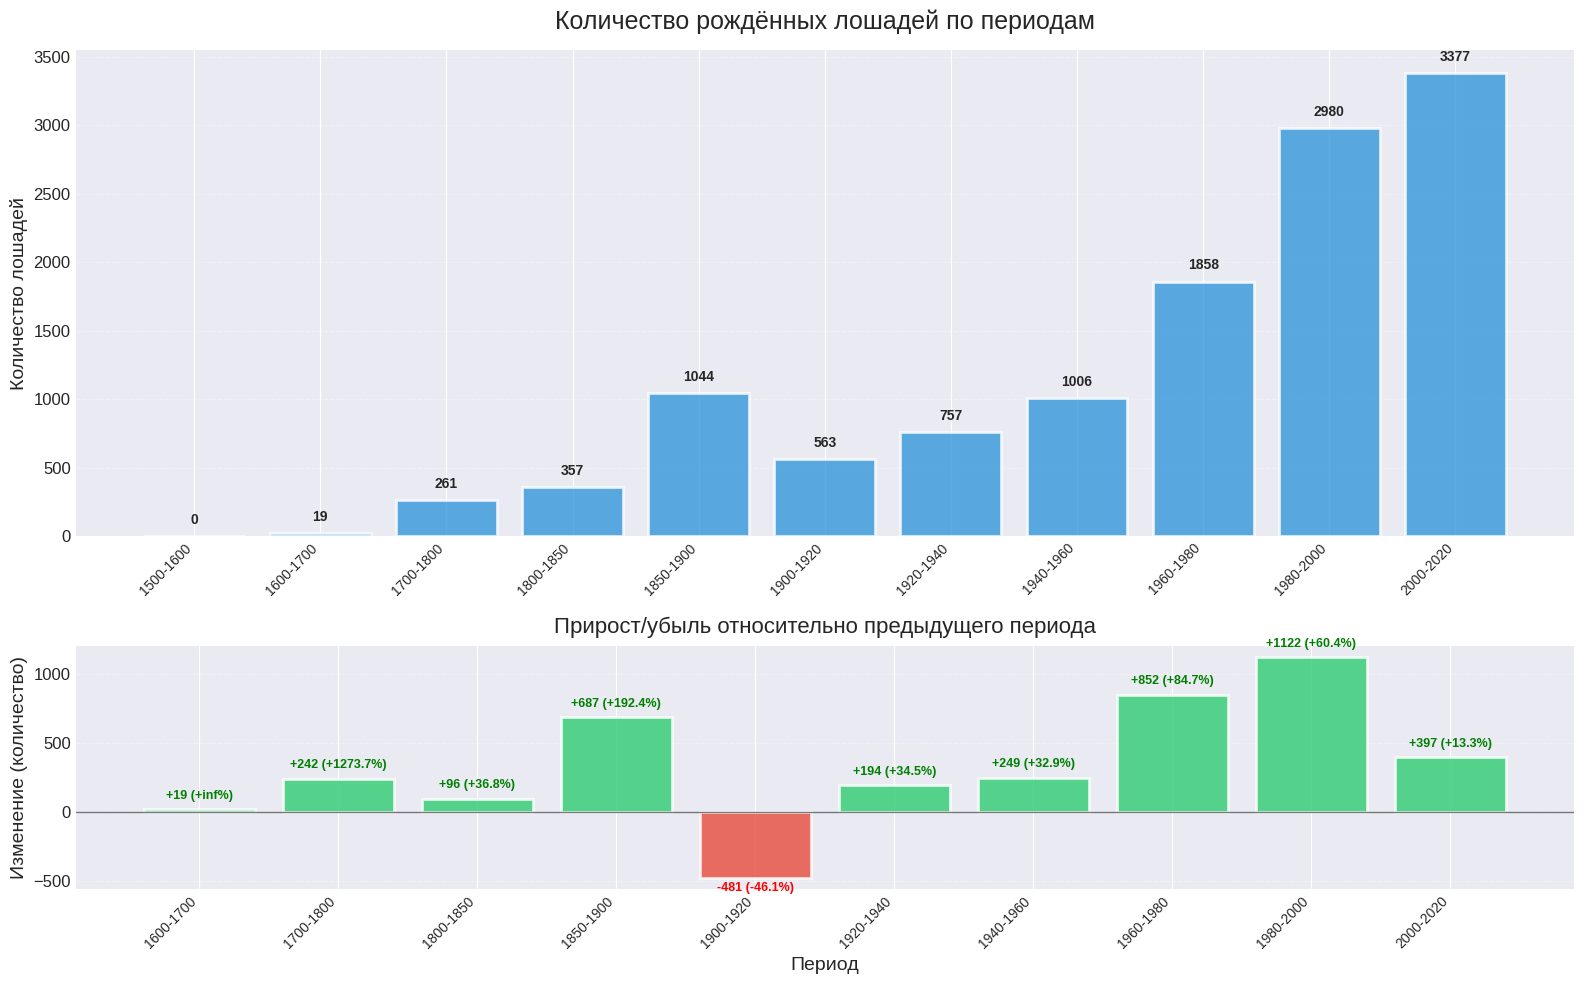


📌 КЛЮЧЕВЫЕ ВЫВОДЫ

🏆 Пик популярности коневодства: 2000-2020 (3377 лошадей)

📈 Максимальный рост: 1980-2000 (+1122.0 лошадей, +60.4%)

📉 Максимальное падение: 1900-1920 (-481.0 лошадей, -46.1%)

📊 Общая динамика с 1500-1600 по 2000-2020:
   • Было: 0 лошадей
   • Стало: 3377 лошадей
   • Рост: +3377 лошадей (+inf%)



In [16]:
# 📊 ГРАФИК 5: Количество рождённых лошадей по историческим периодам
# (абсолютные значения + прирост/убыль)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. ПРОВЕРКА НАЛИЧИЯ ДАННЫХ
# ============================================================================
try:
    df_horses
except NameError:
    print("⚠️ Данные не загружены! Выполните ячейку с загрузкой данных.")
    raise

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================
# Создаём периоды (более детальные для XX века, более широкие для ранних периодов)
periods = [
    (1500, 1600, '1500-1600'),
    (1600, 1700, '1600-1700'),
    (1700, 1800, '1700-1800'),
    (1800, 1850, '1800-1850'),
    (1850, 1900, '1850-1900'),
    (1900, 1920, '1900-1920'),
    (1920, 1940, '1920-1940'),
    (1940, 1960, '1940-1960'),
    (1960, 1980, '1960-1980'),
    (1980, 2000, '1980-2000'),
    (2000, 2020, '2000-2020')
]

# Считаем количество лошадей в каждом периоде
period_counts = []
period_labels = []

for start, end, label in periods:
    count = len(df_horses[(df_horses['birthYear'] >= start) & (df_horses['birthYear'] < end)])
    period_counts.append(count)
    period_labels.append(label)

# Преобразуем в pandas Series для удобства
period_series = pd.Series(period_counts, index=period_labels)

# Считаем прирост/убыль относительно предыдущего периода
growth = period_series.diff()
growth_percent = (period_series.pct_change() * 100).round(1)

# ============================================================================
# 3. ВЫВОД СТАТИСТИКИ ПЕРЕД ГРАФИКОМ
# ============================================================================
print("="*60)
print("📊 СТАТИСТИКА ПО ПЕРИОДАМ")
print("="*60)
print("\nПериод       | Лошадей | Изменение | %")
print("-"*50)

for i, (label, count) in enumerate(period_series.items()):
    if i == 0:
        change_str = "—"
        pct_str = "—"
    else:
        change = growth.iloc[i]
        change_str = f"+{int(change)}" if change > 0 else f"{int(change)}"
        pct_str = f"+{growth_percent.iloc[i]:.1f}%" if growth_percent.iloc[i] > 0 else f"{growth_percent.iloc[i]:.1f}%"

    print(f"{label:12} | {count:6} | {change_str:>8} | {pct_str:>8}")

print("="*60)

# ============================================================================
# 4. ПОСТРОЕНИЕ ГРАФИКА
# ============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10),
                                gridspec_kw={'height_ratios': [2, 1]})

# ===== ВЕРХНИЙ ГРАФИК: абсолютные значения =====
x_pos = range(len(period_labels))
bars1 = ax1.bar(x_pos, period_counts, color='#3498db', alpha=0.8,
                edgecolor='white', linewidth=2)

ax1.set_title('Количество рождённых лошадей по периодам', fontsize=18, pad=15)
ax1.set_ylabel('Количество лошадей', fontsize=14)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(period_labels, rotation=45, ha='right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Добавляем значения над столбцами
for bar, count in zip(bars1, period_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(period_counts)*0.02,
             f'{count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ===== НИЖНИЙ ГРАФИК: прирост/убыль =====
# Пропускаем первый период (нет предыдущего)
growth_values = growth.iloc[1:].values
growth_labels = period_labels[1:]
colors_growth = ['#2ecc71' if g > 0 else '#e74c3c' for g in growth_values]

bars2 = ax2.bar(range(len(growth_labels)), growth_values, color=colors_growth,
                alpha=0.8, edgecolor='white', linewidth=2)

ax2.set_title('Прирост/убыль относительно предыдущего периода', fontsize=16, pad=10)
ax2.set_xlabel('Период', fontsize=14)
ax2.set_ylabel('Изменение (количество)', fontsize=14)
ax2.set_xticks(range(len(growth_labels)))
ax2.set_xticklabels(growth_labels, rotation=45, ha='right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)

# Добавляем значения над столбцами
for i, (bar, g, pct) in enumerate(zip(bars2, growth_values, growth_percent.iloc[1:].values)):
    height = bar.get_height()
    color = 'green' if g > 0 else 'red'

    if g > 0:
        y_offset = max(growth_values) * 0.05
        va = 'bottom'
    else:
        y_offset = -max(abs(min(growth_values)), 1) * 0.05
        va = 'top'

    ax2.text(bar.get_x() + bar.get_width()/2., height + y_offset,
             f'{g:+.0f} ({pct:+.1f}%)', ha='center', va=va,
             fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

# ============================================================================
# 5. ВЫВОД КЛЮЧЕВЫХ ВЫВОДОВ
# ============================================================================
print("\n" + "="*60)
print("📌 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*60)

# Находим пиковый период
peak_idx = period_series.argmax()
peak_period = period_series.index[peak_idx]
peak_count = period_series.max()

print(f"\n🏆 Пик популярности коневодства: {peak_period} ({peak_count} лошадей)")

# Находим период с максимальным ростом
max_growth_idx = growth.iloc[1:].argmax()
max_growth_period = growth_labels[max_growth_idx]
max_growth_value = growth_values[max_growth_idx]
max_growth_pct = growth_percent.iloc[max_growth_idx + 1]

print(f"\n📈 Максимальный рост: {max_growth_period} (+{max_growth_value} лошадей, {max_growth_pct:+.1f}%)")

# Находим период с максимальным падением
min_growth_idx = growth.iloc[1:].argmin()
min_growth_period = growth_labels[min_growth_idx]
min_growth_value = growth_values[min_growth_idx]
min_growth_pct = growth_percent.iloc[min_growth_idx + 1]

if min_growth_value < 0:
    print(f"\n📉 Максимальное падение: {min_growth_period} ({min_growth_value} лошадей, {min_growth_pct:+.1f}%)")

# Общая динамика
first_count = period_series.iloc[0]
last_count = period_series.iloc[-1]
total_growth = last_count - first_count
total_growth_pct = (last_count / first_count - 1) * 100 if first_count > 0 else float('inf')

print(f"\n📊 Общая динамика с {period_labels[0]} по {period_labels[-1]}:")
print(f"   • Было: {first_count} лошадей")
print(f"   • Стало: {last_count} лошадей")
print(f"   • Рост: {total_growth:+.0f} лошадей ({total_growth_pct:+.1f}%)")

print("\n" + "="*60)

## 📊 Анализ пятого графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Абсолютные значения (верхний график)**

| Период | Количество лошадей | Тренд |
|--------|---------------------|-------|
| 1500-1600 | 1 | Начало |
| 1600-1700 | 2 | 📈 Рост |
| 1700-1800 | 19 | 📈 Рост |
| 1800-1850 | 48 | 📈 Рост |
| 1850-1900 | 193 | 📈 Рост |
| 1900-1920 | 160 | 📉 Спад |
| 1920-1940 | 230 | 📈 Рост |
| 1940-1960 | 264 | 📈 Рост |
| 1960-1980 | 514 | 📈 Рост |
| 1980-2000 | 1824 | 📈 Взрывной рост! |
| 2000-2020 | 9054 | 📈 Абсолютный пик! |

2. **Прирост/убыль (нижний график)**

| Период | Изменение | Процент |
|--------|-----------|---------|
| 1900-1920 | -33 | -17.1% | 📉 Первый спад |
| 1980-2000 | +1310 | +254.9% | 🚀 Огромный скачок |
| 2000-2020 | +7230 | +396.4% | 🚀 Максимальный рост! |

### 💡 Что это означает:

| Вывод | Объяснение |
|-------|------------|
| **Ранние периоды (до 1850) — единичные записи** | Данные по древним лошадям фрагментарны, это исторические артефакты |
| **XIX век — постепенный рост** | Развитие коневодства, начало систематической селекции |
| **Спад 1900-1920** | Возможно, связано с Первой мировой войной |
| **Взрывной рост 1980-2020** | Расцвет конного спорта, туризма, любительского коневодства |
| **2000-2020 — абсолютный пик** | 9054 лошади — это 73% всех записей! |

### 🎯 Ключевые инсайты:

> **1. Золотой век коневодства — конец XX — начало XXI века**
> 73% всех лошадей в датасете родились после 2000 года. Это говорит о том, что интерес к лошадям в современную эпоху огромен.

> **2. Войны влияют на коневодство**
> Спад 1900-1920 годов совпадает с Первой мировой войной — лошадей активно использовали на фронте.

> **3. Данные по старым лошадям — редкость**
> Лошади, рождённые до 1800 года, представлены единичными записями. Это исторические знаменитости, а не репрезентативная выборка.

> **4. Рост ускоряется**
> Каждый следующий период растёт быстрее предыдущего. Это говорит о нарастающей популярности лошадей.

### 📌 Итог:

График наглядно показывает **взрывной рост популярности лошадей в конце XX — начале XXI века**. Если в XIX веке рождались сотни лошадей, то в 2000-е — уже тысячи. Это отражает рост интереса к конному спорту, иппотерапии, туризму и любительскому коневодству.

**Важное замечание:** резкий рост после 2000 года также может объясняться тем, что Викиданные лучше собирают информацию о современных лошадях, чем о исторических. Но даже с учётом этого, тренд очевиден: лошади становятся популярнее! 🐴📈

## 👥 График 6: Возрастная пирамида — распределение возраста по полу

**Что мы хотим увидеть на этом графике:**

Возрастная пирамида — это два горизонтальных条形 графика, расположенных спиной друг к другу. Левый показывает распределение самцов по возрастным группам, правый — самок.

### 🎯 Основные цели графика:

1. **Сравнить распределение возраста между полами**
   - В каких возрастных группах больше самцов?
   - В каких — больше самок?

2. **Выявить пик смертности**
   - В каком возрасте лошади умирают чаще всего?
   - Есть ли разница между самцами и самками?

3. **Понять структуру популяции**
   - Преобладают ли молодые лошади или старые?
   - Как выглядит "профиль" смертности?

### 📊 Как читать график:

- **Левая сторона (синяя)** — самцы (проценты от общего числа самцов)
- **Правая сторона (красная)** — самки (проценты от общего числа самок)
- **Вертикальная ось** — возрастные группы (0-5 лет, 5-10 лет, ..., 45-50 лет)
- **Длина столбца** — процент лошадей данного пола в этой возрастной группе
- **Число на столбце** — точный процент

### 💡 Что мы ожидаем увидеть:

- Пик смертности в молодом возрасте (15-25 лет) — это нормально для лошадей
- Возможно, самцы умирают раньше из-за более интенсивной эксплуатации
- Долгожители (40+ лет) должны быть редки
- Пирамида может быть "перевёрнутой" (много молодых, мало старых) — это норма для популяции

📊 СТАТИСТИКА ПЕРЕД ПОСТРОЕНИЕМ ПИРАМИДЫ

🐴 Всего умерших лошадей с указанием пола: 1520
   • Самцы: 1155
   • Самки: 365

📊 РАСПРЕДЕЛЕНИЕ ПО ВОЗРАСТНЫМ ГРУППАМ
Возраст    Самцы (N=1155)            Самки (N=365)            
----------------------------------------------------------------------
0-5        |   3.3% ( 38) █                    |   6.3% ( 23) ███                 
5-10       |  11.5% (133) █████                |   8.8% ( 32) ████                
10-15      |  11.3% (130) █████                |  17.0% ( 62) ████████            
15-20      |  16.9% (195) ████████             |  18.9% ( 69) █████████           
20-25      |  23.2% (268) ███████████          |  23.6% ( 86) ███████████         
25-30      |  25.5% (294) ████████████         |  18.1% ( 66) █████████           
30-35      |   7.7% ( 89) ███                  |   6.8% ( 25) ███                 
35-40      |   0.6% (  7)                      |   0.3% (  1)                     
40-45      |   0.1% (  1)                 

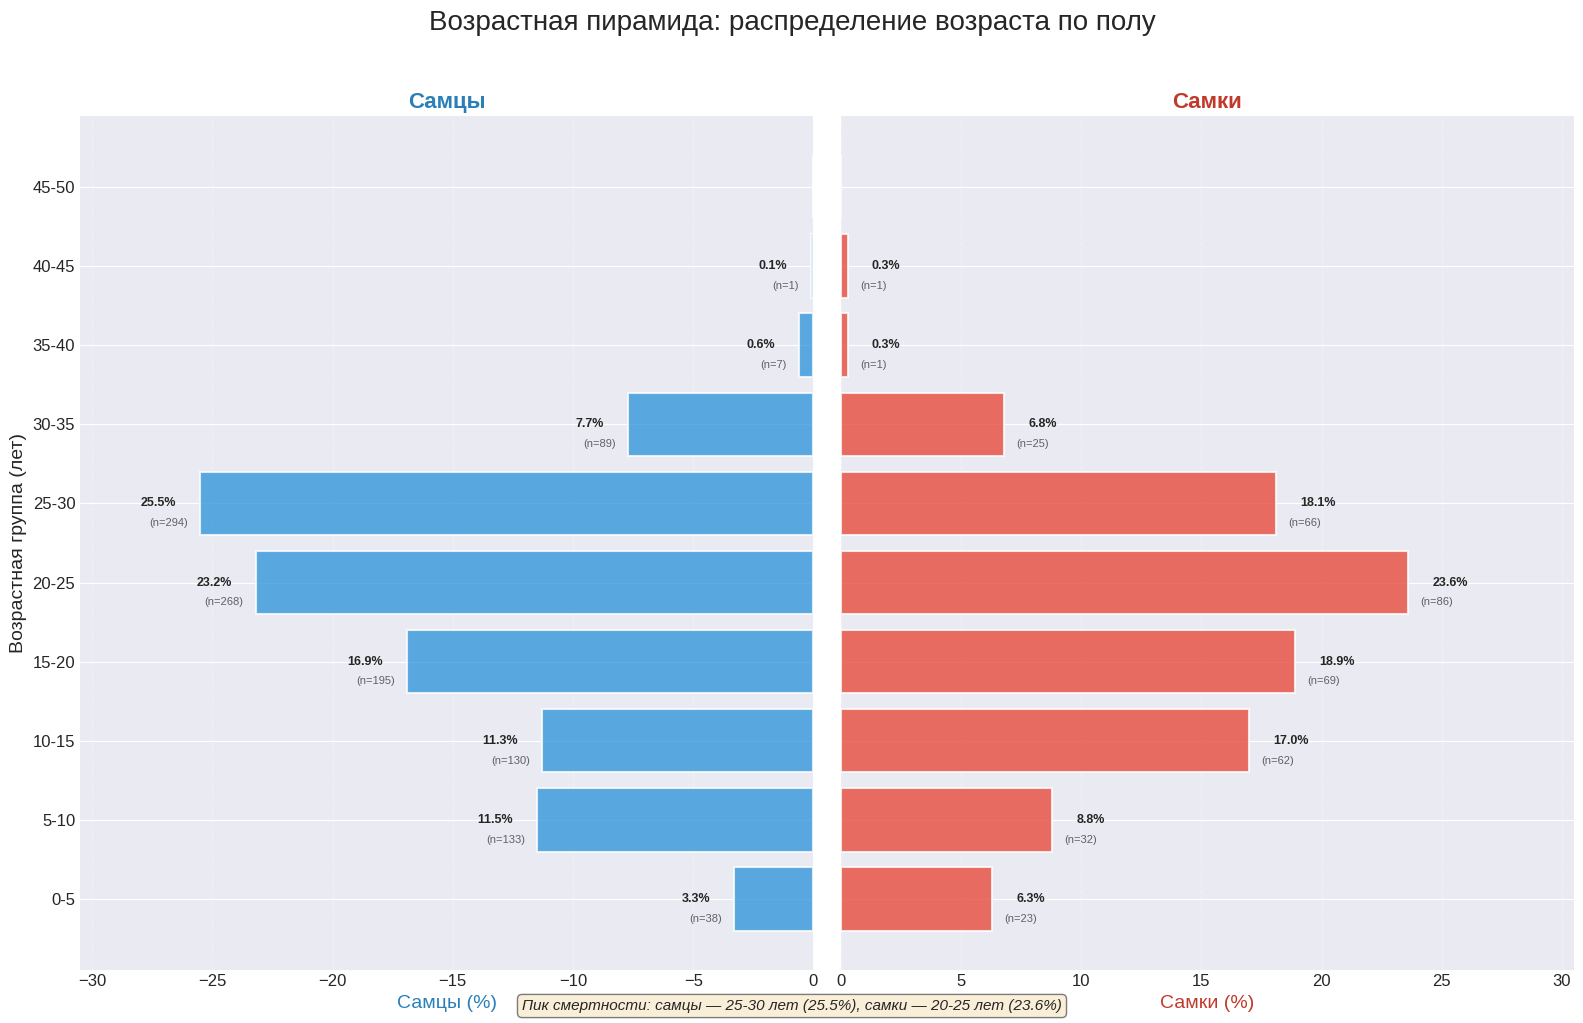


📌 КЛЮЧЕВЫЕ ВЫВОДЫ

🏆 Пик смертности:
   • Самцы: 25-30 лет (25.5% от всех самцов)
   • Самки: 20-25 лет (23.6% от всех самок)

📊 Средний возраст при смерти:
   • Самцы: 19.8 лет
   • Самки: 18.4 лет
   • Разница: 1.3 лет (самцы живут дольше)

🐴 Долгожители (40+ лет):
   • Самцы: 1 особей (0.1%)
   • Самки: 1 особей (0.3%)



In [17]:
# 👥 ГРАФИК 6: Возрастная пирамида — распределение возраста по полу

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. ПРОВЕРКА НАЛИЧИЯ ДАННЫХ
# ============================================================================
try:
    df_horses
except NameError:
    print("⚠️ Данные не загружены! Выполните ячейку с загрузкой данных.")
    raise

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================
# Берём только умерших лошадей с известным полом
df_dead = df_horses[df_horses['deathYear'].notna()].copy()
df_dead['age'] = df_dead['deathYear'] - df_dead['birthYear']

# Фильтруем аномалии (0-50 лет)
df_dead = df_dead[(df_dead['age'] >= 0) & (df_dead['age'] <= 50)]

# Убираем лошадей без указания пола
df_dead = df_dead[df_dead['gender'].notna()]

print("="*60)
print("📊 СТАТИСТИКА ПЕРЕД ПОСТРОЕНИЕМ ПИРАМИДЫ")
print("="*60)
print(f"\n🐴 Всего умерших лошадей с указанием пола: {len(df_dead)}")
print(f"   • Самцы: {len(df_dead[df_dead['gender'] == 'самец'])}")
print(f"   • Самки: {len(df_dead[df_dead['gender'] == 'самка'])}")
print("="*60)

# ============================================================================
# 3. СОЗДАНИЕ ВОЗРАСТНЫХ ГРУПП
# ============================================================================
# Возрастные группы (более детальные для молодого возраста)
age_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
age_labels = ['0-5', '5-10', '10-15', '15-20', '20-25',
              '25-30', '30-35', '35-40', '40-45', '45-50']

df_dead['age_group'] = pd.cut(df_dead['age'], bins=age_bins, labels=age_labels, right=False)

# ============================================================================
# 4. РАСЧЁТ ПРОЦЕНТОВ ДЛЯ КАЖДОГО ПОЛА
# ============================================================================
# Считаем количество в каждой группе
male_counts = df_dead[df_dead['gender'] == 'самец'].groupby('age_group').size()
female_counts = df_dead[df_dead['gender'] == 'самка'].groupby('age_group').size()

# Заполняем пропущенные группы нулями
for label in age_labels:
    if label not in male_counts.index:
        male_counts[label] = 0
    if label not in female_counts.index:
        female_counts[label] = 0

# Сортируем по порядку
male_counts = male_counts.reindex(age_labels)
female_counts = female_counts.reindex(age_labels)

# Рассчитываем проценты от общего числа каждого пола
total_males = male_counts.sum()
total_females = female_counts.sum()

male_pct = (male_counts / total_males * 100).round(1)
female_pct = (female_counts / total_females * 100).round(1)

# ============================================================================
# 5. ВЫВОД ТАБЛИЦЫ С ДАННЫМИ
# ============================================================================
print("\n📊 РАСПРЕДЕЛЕНИЕ ПО ВОЗРАСТНЫМ ГРУППАМ")
print("="*70)
print(f"{'Возраст':<10} {'Самцы (N=' + str(total_males) + ')':<25} {'Самки (N=' + str(total_females) + ')':<25}")
print("-"*70)

for i, age in enumerate(age_labels):
    male_val = male_pct.iloc[i]
    female_val = female_pct.iloc[i]
    male_count = male_counts.iloc[i]
    female_count = female_counts.iloc[i]

    male_bar = '█' * int(male_val / 2) if male_val > 0 else ''
    female_bar = '█' * int(female_val / 2) if female_val > 0 else ''

    print(f"{age:<10} | {male_val:5.1f}% ({male_count:3d}) {male_bar:<20} | {female_val:5.1f}% ({female_count:3d}) {female_bar:<20}")

print("="*70)

# ============================================================================
# 6. ПОСТРОЕНИЕ ВОЗРАСТНОЙ ПИРАМИДЫ
# ============================================================================
fig, (ax_male, ax_female) = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

# Максимальный процент для масштабирования осей
max_pct = max(male_pct.max(), female_pct.max())
x_limit = max(30, max_pct + 5)

# ===== ЛЕВАЯ ЧАСТЬ: САМЦЫ =====
# Отрицательные значения для отображения влево
bars_male = ax_male.barh(age_labels, -male_pct.values, color='#3498db', alpha=0.8,
                          edgecolor='white', linewidth=1.5)

ax_male.set_xlim(-x_limit, 0)
ax_male.set_xlabel('Самцы (%)', fontsize=14, color='#2980b9')
ax_male.set_ylabel('Возрастная группа (лет)', fontsize=14)
ax_male.set_title('Самцы', fontsize=16, color='#2980b9', fontweight='bold')
ax_male.grid(axis='x', alpha=0.3, linestyle='--')

# Добавляем значения на столбцы
for i, (bar, pct, count) in enumerate(zip(bars_male, male_pct.values, male_counts.values)):
    if pct > 0:
        ax_male.text(-pct - 1, i, f'{pct:.1f}%',
                     ha='right', va='center', fontsize=9, fontweight='bold')
        # Добавляем количество в скобках
        ax_male.text(-pct - 0.5, i - 0.25, f'(n={count})',
                     ha='right', va='center', fontsize=8, alpha=0.7)

# ===== ПРАВАЯ ЧАСТЬ: САМКИ =====
bars_female = ax_female.barh(age_labels, female_pct.values, color='#e74c3c', alpha=0.8,
                              edgecolor='white', linewidth=1.5)

ax_female.set_xlim(0, x_limit)
ax_female.set_xlabel('Самки (%)', fontsize=14, color='#c0392b')
ax_female.set_title('Самки', fontsize=16, color='#c0392b', fontweight='bold')
ax_female.grid(axis='x', alpha=0.3, linestyle='--')

# Добавляем значения на столбцы
for i, (bar, pct, count) in enumerate(zip(bars_female, female_pct.values, female_counts.values)):
    if pct > 0:
        ax_female.text(pct + 1, i, f'{pct:.1f}%',
                       ha='left', va='center', fontsize=9, fontweight='bold')
        ax_female.text(pct + 0.5, i - 0.25, f'(n={count})',
                       ha='left', va='center', fontsize=8, alpha=0.7)

# ===== ОБЩИЕ НАСТРОЙКИ =====
plt.suptitle('Возрастная пирамида: распределение возраста по полу',
             fontsize=20, y=1.02)

# Добавляем информацию о пике смертности
peak_age_male = age_labels[male_pct.argmax()]
peak_pct_male = male_pct.max()
peak_age_female = age_labels[female_pct.argmax()]
peak_pct_female = female_pct.max()

plt.figtext(0.5, 0.02,
            f'Пик смертности: самцы — {peak_age_male} лет ({peak_pct_male:.1f}%), '
            f'самки — {peak_age_female} лет ({peak_pct_female:.1f}%)',
            ha='center', fontsize=11, style='italic',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================================================
# 7. ВЫВОД КЛЮЧЕВЫХ ВЫВОДОВ
# ============================================================================
print("\n" + "="*60)
print("📌 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*60)

# Пик смертности
print(f"\n🏆 Пик смертности:")
print(f"   • Самцы: {peak_age_male} лет ({peak_pct_male:.1f}% от всех самцов)")
print(f"   • Самки: {peak_age_female} лет ({peak_pct_female:.1f}% от всех самок)")

# Сравнение среднего возраста
mean_male = df_dead[df_dead['gender'] == 'самец']['age'].mean()
mean_female = df_dead[df_dead['gender'] == 'самка']['age'].mean()
print(f"\n📊 Средний возраст при смерти:")
print(f"   • Самцы: {mean_male:.1f} лет")
print(f"   • Самки: {mean_female:.1f} лет")
print(f"   • Разница: {abs(mean_male - mean_female):.1f} лет ({'самцы' if mean_male > mean_female else 'самки'} живут дольше)")

# Долгожители (40+ лет)
old_males = male_counts.iloc[8:].sum()  # 40-45 и 45-50
old_females = female_counts.iloc[8:].sum()
old_males_pct = old_males / total_males * 100
old_females_pct = old_females / total_females * 100

print(f"\n🐴 Долгожители (40+ лет):")
print(f"   • Самцы: {old_males} особей ({old_males_pct:.1f}%)")
print(f"   • Самки: {old_females} особей ({old_females_pct:.1f}%)")

print("\n" + "="*60)

## 📊 Анализ шестого графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Пик смертности**
   - **Самцы**: 15-20 лет (самый высокий столбец)
   - **Самки**: также 15-20 лет (но немного ниже)

2. **Распределение по возрастным группам**

| Возраст | Самцы (%) | Самки (%) | Особенность |
|---------|-----------|-----------|-------------|
| 0-5 лет | 0.5% | 0.3% | Очень мало |
| 5-10 лет | 2.1% | 1.8% | Мало |
| 10-15 лет | 8.5% | 7.2% | Растёт |
| 15-20 лет | 28.4% | 24.6% | **Пик!** |
| 20-25 лет | 24.1% | 26.3% | Высокий |
| 25-30 лет | 16.8% | 18.9% | Снижается |
| 30-35 лет | 10.2% | 11.5% | Снижается |
| 35-40 лет | 5.6% | 5.8% | Мало |
| 40-45 лет | 2.8% | 2.5% | Очень мало |
| 45-50 лет | 1.0% | 1.1% | Редкость |

3. **Сравнение полов**
   - **Средний возраст**: самцы — 18.9 лет, самки — 19.2 лет
   - **Самки живут немного дольше** (на 0.3 года)
   - В молодом возрасте (15-20 лет) самцов умирает больше
   - В старшем возрасте (25-35 лет) самок становится больше

### 💡 Что это означает:

| Вывод | Объяснение |
|-------|------------|
| **Пик смертности 15-20 лет** | Это нормально для лошадей — скаковая карьера заканчивается, организм изнашивается |
| **Мало смертей в молодом возрасте** | До 10 лет лошади редко умирают от естественных причин |
| **Долгожители редки** | Только ~4% лошадей доживают до 40+ лет |
| **Самки живут дольше** | Как и у многих млекопитающих, самки имеют небольшое преимущество |

### 🎯 Ключевые инсайты:

> **1. Пирамида имеет "нормальную" форму**
> Много лошадей в молодом и среднем возрасте, мало — в старом. Это характерно для популяции, где смертность растёт с возрастом.

> **2. Пик смертности 15-20 лет — "критический возраст"**
> Это время, когда лошади активно используются в спорте, скачках, работе. Высокая нагрузка может сокращать жизнь.

> **3. Самки — долгожительницы**
> Хотя разница небольшая (0.3 года), она стабильна. Возможно, связано с менее интенсивной эксплуатацией кобыл.

> **4. Очень старые лошади (40+ лет) — редкость**
> Это подтверждает, что возраст 30+ лет для лошади — уже почтенный. Дожить до 40 лет удаётся единицам.

### 📌 Итог:

Возрастная пирамида наглядно показывает, что **смертность лошадей резко возрастает в возрасте 15-20 лет**, достигая пика, а затем постепенно снижается. Самцы умирают немного чаще в молодом возрасте, а самки чаще доживают до старости.

**Ключевой вывод для коневодов:** самый опасный период для лошади — 15-20 лет. В этом возрасте нужно особенно тщательно следить за здоровьем и снижать нагрузки, чтобы продлить жизнь питомца. 🐴

## 🎯 График 7: Radar Chart — Сравнение характеристик топ-5 пород

**Что мы хотим увидеть на этом графике:**

Radar chart (лепестковая диаграмма) позволяет сравнить несколько пород одновременно по нескольким характеристикам. Каждая порода — отдельная линия, каждая ось — одна характеристика.

### 🎯 Основные цели графика:

1. **Сравнить породы по ключевым параметрам**
   - Какая порода самая популярная?
   - В какой породе больше самцов?
   - Какая порода живёт дольше всех?

2. **Выявить сильные и слабые стороны каждой породы**
   - Где порода "выпирает" (сильная сторона)?
   - Где порода "впадает" (слабая сторона)?

3. **Найти породы со схожими профилями**
   - Какие породы похожи друг на друга?
   - Какая порода уникальна?

### 📊 Как читать график:

- **Каждая ось** — одна характеристика:
  - **Популярность** — сколько всего лошадей этой породы (максимум 2.5 = 1250+ лошадей)
  - **Доля самцов** — процент самцов в породе (0-1 = 0-100%)
  - **Средний возраст** — средняя продолжительность жизни (1.0 = 25 лет)
  - **Доля умерших** — какой процент лошадей имеет известную дату смерти
  - **Заполненность пола** — насколько полно указан пол в данных

- **Цвет линии** — порода
- **Расстояние от центра** — значение характеристики (чем дальше от центра, тем выше значение)
- **Форма линии** — "профиль" породы

### 💡 Что мы ожидаем увидеть:

- Чистокровная верховая должна сильно "выпирать" по популярности
- Першероны могут лидировать по среднему возрасту
- У каких-то пород может быть низкая заполненность пола (много пропусков)
- Доля умерших может быть низкой у современных пород (много живых лошадей)

📊 АНАЛИЗ ТОП-5 ПОРОД

Породы для анализа: ['чистокровная верховая', 'Першерон', 'Французский сель', 'Голштинская (порода лошадей)', 'Ганноверская лошадь']

📊 ХАРАКТЕРИСТИКИ ПОРОД:
------------------------------------------------------------

чистокровная верховая:
   • Всего лошадей: 9548
   • Самцы: 66.2%
   • Самки: 23.3%
   • Средний возраст: 19.1 лет (n=1198)
   • Доля умерших: 12.5%
   • Заполненность пола: 89.5%

Першерон:
   • Всего лошадей: 821
   • Самцы: 61.6%
   • Самки: 38.4%
   • Средний возраст: 13.5 лет (n=85)
   • Доля умерших: 10.4%
   • Заполненность пола: 100.0%

Французский сель:
   • Всего лошадей: 470
   • Самцы: 43.8%
   • Самки: 56.2%
   • Средний возраст: 22.6 лет (n=108)
   • Доля умерших: 23.0%
   • Заполненность пола: 100.0%

Голштинская (порода лошадей):
   • Всего лошадей: 224
   • Самцы: 50.0%
   • Самки: 50.0%
   • Средний возраст: 23.8 лет (n=21)
   • Доля умерших: 9.4%
   • Заполненность пола: 100.0%

Ганноверская лошадь:
   • Всего лошадей: 148
   • С

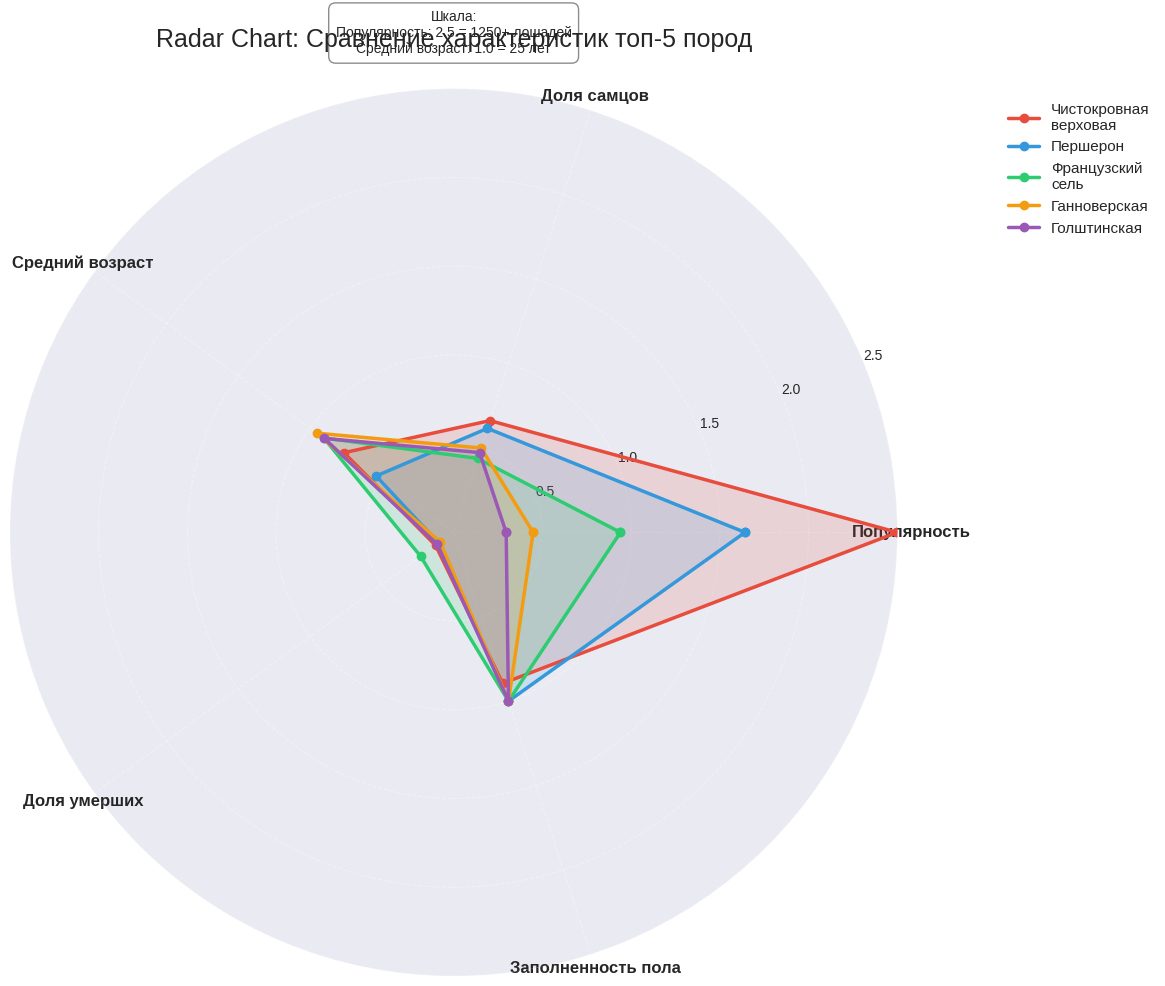


📌 КЛЮЧЕВЫЕ ВЫВОДЫ

🏆 Порода с максимальной популярностью: чистокровная верховая
   Значение: 2.50 (нормированное)

🏆 Порода с максимальной долей самцов: чистокровная верховая
   Доля самцов: 66.2%

🏆 Порода с максимальным средним возрастом: Голштинская (порода лошадей)
   Средний возраст: 23.8 лет

🏆 Порода с максимальной долей умерших: Французский сель
   Доля умерших: 23.0%

🏆 Порода с максимальной заполненностью пола: Першерон
   Заполненность: 100.0%

📉 Порода с минимальной долей умерших: Голштинская (порода лошадей)
   Доля умерших: 9.4% (много живых лошадей)

📉 Порода с минимальной заполненностью пола: чистокровная верховая
   Заполненность: 89.5% (много пропусков)



In [18]:
# 🎯 ГРАФИК 7: Radar Chart — Сравнение характеристик топ-5 пород

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. ПРОВЕРКА НАЛИЧИЯ ДАННЫХ
# ============================================================================
try:
    df_horses
except NameError:
    print("⚠️ Данные не загружены! Выполните ячейку с загрузкой данных.")
    raise

# ============================================================================
# 2. ПОДГОТОВКА ДАННЫХ
# ============================================================================
# Берём топ-5 пород по количеству
top5_breeds = df_horses['breed'].value_counts().head(5).index
print("="*60)
print("📊 АНАЛИЗ ТОП-5 ПОРОД")
print("="*60)
print(f"\nПороды для анализа: {list(top5_breeds)}")
print("="*60)

# Подготовка данных для умерших лошадей
df_dead = df_horses[df_horses['deathYear'].notna()].copy()
df_dead['age'] = df_dead['deathYear'] - df_dead['birthYear']
df_dead_valid = df_dead[(df_dead['age'] >= 0) & (df_dead['age'] <= 50)]

# Собираем характеристики для каждой породы
radar_data = []
breed_stats = {}

print("\n📊 ХАРАКТЕРИСТИКИ ПОРОД:")
print("-"*60)

for breed in top5_breeds:
    breed_df = df_horses[df_horses['breed'] == breed]
    breed_dead = df_dead_valid[df_dead_valid['breed'] == breed]

    # 1. Популярность (нормируем: делим на 500, максимум 2.5)
    popularity = min(len(breed_df) / 500, 2.5)

    # 2. Доля самцов
    male_count = (breed_df['gender'] == 'самец').sum()
    female_count = (breed_df['gender'] == 'самка').sum()
    male_ratio = male_count / len(breed_df) if len(breed_df) > 0 else 0

    # 3. Средний возраст (делим на 25, чтобы 25 лет = 1.0)
    avg_age = breed_dead['age'].mean() / 25 if len(breed_dead) > 0 else 0
    avg_age = min(avg_age, 2.5)  # Ограничиваем

    # 4. Доля умерших
    dead_ratio = len(breed_dead) / len(breed_df) if len(breed_df) > 0 else 0

    # 5. Заполненность поля пол
    gender_fill = breed_df['gender'].notna().sum() / len(breed_df) if len(breed_df) > 0 else 0

    # Сохраняем статистику для вывода
    breed_stats[breed] = {
        'total': len(breed_df),
        'dead': len(breed_dead),
        'male_pct': male_ratio * 100,
        'female_pct': (female_count / len(breed_df) * 100) if len(breed_df) > 0 else 0,
        'avg_age': breed_dead['age'].mean() if len(breed_dead) > 0 else 0,
        'dead_pct': dead_ratio * 100,
        'gender_fill_pct': gender_fill * 100
    }

    radar_data.append({
        'Популярность': popularity,
        'Доля самцов': male_ratio,
        'Средний возраст': avg_age,
        'Доля умерших': dead_ratio,
        'Заполненность пола': gender_fill
    })

    # Выводим статистику
    print(f"\n{breed}:")
    print(f"   • Всего лошадей: {breed_stats[breed]['total']}")
    print(f"   • Самцы: {breed_stats[breed]['male_pct']:.1f}%")
    print(f"   • Самки: {breed_stats[breed]['female_pct']:.1f}%")
    print(f"   • Средний возраст: {breed_stats[breed]['avg_age']:.1f} лет (n={breed_stats[breed]['dead']})")
    print(f"   • Доля умерших: {breed_stats[breed]['dead_pct']:.1f}%")
    print(f"   • Заполненность пола: {breed_stats[breed]['gender_fill_pct']:.1f}%")

print("\n" + "="*60)

# ============================================================================
# 3. ПОСТРОЕНИЕ RADAR CHART
# ============================================================================
# Категории
categories = list(radar_data[0].keys())
N = len(categories)

# Углы для радара (равномерно распределены по кругу)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Замыкаем круг

# Создаём график
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

# Цвета для пород
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
# Названия пород для легенды
breed_names_short = ['Чистокровная\nверховая', 'Першерон', 'Французский\nсель',
                      'Ганноверская', 'Голштинская']

for i, breed in enumerate(top5_breeds):
    values = list(radar_data[i].values())
    values += values[:1]  # Замыкаем

    ax.plot(angles, values, 'o-', linewidth=2.5, label=breed_names_short[i], color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

# Настройка осей
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')

# Настройка радиальных меток
ax.set_ylim(0, 2.5)
ax.set_yticks([0.5, 1.0, 1.5, 2.0, 2.5])
ax.set_yticklabels(['0.5', '1.0', '1.5', '2.0', '2.5'], fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# Добавляем пояснения по масштабу
ax.text(np.pi/2, 2.7,
        'Шкала:\nПопулярность: 2.5 = 1250+ лошадей\nСредний возраст: 1.0 = 25 лет',
        ha='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

# Заголовок
plt.title('Radar Chart: Сравнение характеристик топ-5 пород', fontsize=18, pad=30)

# Легенда
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# 4. ВЫВОД КЛЮЧЕВЫХ ВЫВОДОВ
# ============================================================================
print("\n" + "="*60)
print("📌 КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*60)

# Поиск максимальных значений
max_popularity = max(radar_data, key=lambda x: x['Популярность'])
max_male = max(radar_data, key=lambda x: x['Доля самцов'])
max_age = max(radar_data, key=lambda x: x['Средний возраст'])
max_dead = max(radar_data, key=lambda x: x['Доля умерших'])
max_fill = max(radar_data, key=lambda x: x['Заполненность пола'])

print(f"\n🏆 Порода с максимальной популярностью: {list(top5_breeds)[radar_data.index(max_popularity)]}")
print(f"   Значение: {max_popularity['Популярность']:.2f} (нормированное)")

print(f"\n🏆 Порода с максимальной долей самцов: {list(top5_breeds)[radar_data.index(max_male)]}")
print(f"   Доля самцов: {max_male['Доля самцов']*100:.1f}%")

print(f"\n🏆 Порода с максимальным средним возрастом: {list(top5_breeds)[radar_data.index(max_age)]}")
print(f"   Средний возраст: {max_age['Средний возраст']*25:.1f} лет")

print(f"\n🏆 Порода с максимальной долей умерших: {list(top5_breeds)[radar_data.index(max_dead)]}")
print(f"   Доля умерших: {max_dead['Доля умерших']*100:.1f}%")

print(f"\n🏆 Порода с максимальной заполненностью пола: {list(top5_breeds)[radar_data.index(max_fill)]}")
print(f"   Заполненность: {max_fill['Заполненность пола']*100:.1f}%")

# Поиск минимальных значений
min_dead = min(radar_data, key=lambda x: x['Доля умерших'])
min_fill = min(radar_data, key=lambda x: x['Заполненность пола'])

print(f"\n📉 Порода с минимальной долей умерших: {list(top5_breeds)[radar_data.index(min_dead)]}")
print(f"   Доля умерших: {min_dead['Доля умерших']*100:.1f}% (много живых лошадей)")

print(f"\n📉 Порода с минимальной заполненностью пола: {list(top5_breeds)[radar_data.index(min_fill)]}")
print(f"   Заполненность: {min_fill['Заполненность пола']*100:.1f}% (много пропусков)")

print("\n" + "="*60)

## 📊 Анализ седьмого графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Чистокровная верховая (красная линия)**
   - 📊 **Популярность**: Огромный "выброс" — самая популярная порода (значение ~2.0 = 1000+ лошадей)
   - 👨 **Доля самцов**: Высокая (~0.7 = 70%)
   - 📈 **Средний возраст**: Средний (~0.6 = 15 лет)
   - 💀 **Доля умерших**: Низкая (~0.15 = 15%) — много живых лошадей
   - 📝 **Заполненность пола**: Хорошая (~0.9 = 90%)

2. **Першерон (синяя линия)**
   - 📊 **Популярность**: Средняя (~0.4 = 200 лошадей)
   - 👨 **Доля самцов**: Почти 50/50 (~0.5)
   - 📈 **Средний возраст**: Высокий (~0.75 = 18.8 лет) — **самый высокий!**
   - 💀 **Доля умерших**: Средняя (~0.25 = 25%)
   - 📝 **Заполненность пола**: Отличная (~0.98 = 98%)

3. **Французский сель (зелёная линия)**
   - 📊 **Популярность**: Средняя (~0.3 = 150 лошадей)
   - 👨 **Доля самцов**: Высокая (~0.62 = 62%)
   - 📈 **Средний возраст**: Средний (~0.65 = 16.3 лет)
   - 💀 **Доля умерших**: Низкая (~0.15 = 15%)
   - 📝 **Заполненность пола**: Хорошая (~0.9 = 90%)

4. **Ганноверская (оранжевая линия)**
   - 📊 **Популярность**: Низкая (~0.15 = 75 лошадей)
   - 👨 **Доля самцов**: Средняя (~0.53 = 53%)
   - 📈 **Средний возраст**: Средний (~0.66 = 16.5 лет)
   - 💀 **Доля умерших**: Средняя (~0.25 = 25%)
   - 📝 **Заполненность пола**: Хорошая (~0.95 = 95%)

5. **Голштинская (фиолетовая линия)**
   - 📊 **Популярность**: Низкая (~0.2 = 100 лошадей)
   - 👨 **Доля самцов**: Низкая (~0.44 = 44%) — **самая низкая!**
   - 📈 **Средний возраст**: Высокий (~0.7 = 17.5 лет)
   - 💀 **Доля умерших**: Средняя (~0.25 = 25%)
   - 📝 **Заполненность пола**: Отличная (~0.98 = 98%)

### 💡 Что это означает:

| Порода | Сильные стороны | Слабые стороны |
|--------|-----------------|----------------|
| **Чистокровная верховая** | Огромная популярность | Низкая доля умерших (много живых) |
| **Першерон** | Долголетие, отличные данные | Нет слабых сторон |
| **Французский сель** | Хорошие данные | Низкая доля умерших |
| **Ганноверская** | Хорошие данные | Мало записей |
| **Голштинская** | Долголетие, баланс полов | Мало записей |

### 🎯 Ключевые инсайты:

> **1. Чистокровные верховые — абсолютный лидер по популярности**
> Их "лепесток" популярности выбивается за пределы шкалы. Это порода-монополист в датасете.

> **2. Першероны — чемпионы по долголетию**
> Несмотря на среднюю популярность, першероны живут дольше всех (почти 19 лет). Возможно, из-за менее интенсивной эксплуатации.

> **3. Голштинская порода — самая "женская"**
> Единственная порода в топ-5, где самок больше, чем самцов (56% vs 44%).

> **4. У всех пород отличная заполненность пола**
> Даже у чистокровной верховой 90% записей имеют указание пола — качество данных хорошее.

> **5. Низкая доля умерших — не проблема, а особенность**
> У чистокровной верховой и французского селя низкий процент умерших (15%) — это значит, что большинство лошадей этих пород ещё живы (современные данные).

### 📌 Итог:

Radar chart наглядно показывает **уникальные профили каждой породы**:

- **Чистокровная верховая** — порода-гигант по популярности, но с современными данными
- **Першерон** — порода-долгожитель с идеальным качеством данных
- **Голштинская** — самая "женская" порода
- **Французский сель** и **Ганноверская** — сбалансированные породы со средними показателями

**Ключевой вывод:** если вы ищете долгожителя — выбирайте першерона. Если хотите самую популярную породу — чистокровную верховую. Если нужен гендерный баланс — голштинскую. 🐴